# 05. Machine Learning Modeling

## 1. Introduction

This notebook represents the model development stage of the Customer Intelligence Platform.

The objective is to build, validate, and compare supervised machine learning models for predicting customer satisfaction using the modeling dataset prepared during the feature engineering stage.

The prediction task is formulated as a binary classification problem:

- `1` represents a satisfied customer.
- `0` represents an unsatisfied customer.

The modeling workflow is designed around reproducibility and data leakage prevention. Numerical and categorical preprocessing operations are fitted exclusively on the training data through Scikit-learn pipelines.

The notebook covers:

- Modeling dataset validation
- Feature type identification
- Numerical scaling
- Categorical encoding
- Baseline model development
- Logistic Regression
- Decision Tree
- Random Forest
- Model comparison
- Cross-validation
- Class imbalance assessment
- Hyperparameter optimization
- Feature importance analysis
- Best model selection

The final outcome of this notebook will be a validated machine learning pipeline that can be evaluated further and eventually integrated into the Flask deployment layer.

## 2. Table of Contents

1. Introduction
2. Table of Contents
3. Import Libraries
4. Load Modeling Data
5. Initial Modeling Dataset Validation
6. Feature Type Identification
7. Preprocessing Pipeline
8. Baseline Logistic Regression
9. Baseline Model Evaluation
10. Dummy Classifier Benchmark
11. Decision Tree
12. Random Forest
13. Initial Model Comparison
14. Cross-Validation
15. Class Imbalance Analysis
16. Hyperparameter Tuning
17. Tuned Model Comparison
18. Best Model Selection
19. Feature Importance
20. Prediction Probability & Threshold Analysis
21. Final Modeling Validation
22. Model Serialization
23. Modeling Summary & Conclusion

## 3. Import Libraries

The required libraries for data manipulation, preprocessing, model development, cross-validation, hyperparameter optimization, and performance evaluation are imported below.

The modeling workflow primarily relies on Scikit-learn pipelines to ensure that preprocessing and model training remain reproducible and leakage-safe.

In [1]:
from pathlib import Path
import warnings
import seaborn as sns

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import (
    cross_validate,
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)
from sklearn.metrics import make_scorer
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

RANDOM_STATE = 42

## 4. Load Modeling Data

The training and testing datasets generated during the feature engineering stage are loaded in this section.

Using the exported datasets ensures consistency across the project and guarantees that every machine learning experiment is performed on the same train-test split.

The testing dataset remains completely isolated from preprocessing, model training, cross-validation, and hyperparameter optimization in order to prevent information leakage and preserve an unbiased evaluation of model performance.

In [2]:
processed_data_path = Path("../data/processed")

X_train = pd.read_csv(
    processed_data_path / "X_train.csv"
)

X_test = pd.read_csv(
    processed_data_path / "X_test.csv"
)

y_train = (
    pd.read_csv(
        processed_data_path / "y_train.csv"
    )
    .squeeze("columns")
)

y_test = (
    pd.read_csv(
        processed_data_path / "y_test.csv"
    )
    .squeeze("columns")
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (79379, 27)
X_test : (19845, 27)
y_train: (79379,)
y_test : (19845,)


## 5. Initial Modeling Dataset Validation

Before developing machine learning models, the integrity of the training and testing datasets must be verified.

The validation process confirms that:

- The train and test datasets share the same feature structure.
- No missing values remain.
- No duplicate feature names exist.
- The target variable contains valid binary labels.
- The class distribution is preserved after the stratified train-test split.

Performing these checks before preprocessing helps prevent silent data quality issues and ensures a reliable foundation for model development.

In [3]:
print("Training observations :", X_train.shape[0])
print("Testing observations  :", X_test.shape[0])

print("\nTraining features :", X_train.shape[1])
print("Testing features  :", X_test.shape[1])

Training observations : 79379
Testing observations  : 19845

Training features : 27
Testing features  : 27


### Feature Consistency

The training and testing datasets should contain exactly the same feature columns in the same order.

In [4]:
feature_alignment = X_train.columns.equals(X_test.columns)

print("Feature alignment:", feature_alignment)

Feature alignment: True


### Missing Value Validation

The modeling datasets should not contain any missing values prior to preprocessing.

In [5]:
missing_summary = pd.DataFrame({
    "Missing Values": [
        X_train.isna().sum().sum(),
        X_test.isna().sum().sum(),
        y_train.isna().sum(),
        y_test.isna().sum()
    ]
},
index=[
    "X_train",
    "X_test",
    "y_train",
    "y_test"
])

missing_summary

,Missing Values
X_train,0
X_test,0
y_train,0
y_test,0


### Duplicate Feature Validation

Duplicate feature names can lead to unexpected behavior during preprocessing and model training. Therefore, feature names are validated before building the preprocessing pipeline.

In [6]:
duplicate_features = X_train.columns[
    X_train.columns.duplicated()
].tolist()

print("Duplicate feature columns:")
print(duplicate_features)

Duplicate feature columns:
[]


### Target Validation

The target variable is expected to represent a binary classification problem with two valid classes:

- 0 → Unsatisfied Customer
- 1 → Satisfied Customer

In [7]:
print("Training target classes:")
print(sorted(y_train.unique()))

print("\nTesting target classes:")
print(sorted(y_test.unique()))

Training target classes:
[np.int64(0), np.int64(1)]

Testing target classes:
[np.int64(0), np.int64(1)]


In [8]:
target_distribution = pd.DataFrame({
    "Train Count": y_train.value_counts().sort_index(),
    "Train (%)": (
        y_train.value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    ),
    "Test Count": y_test.value_counts().sort_index(),
    "Test (%)": (
        y_test.value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

target_distribution.index = [
    "Unsatisfied (0)",
    "Satisfied (1)"
]

target_distribution

,Train Count,Train (%),Test Count,Test (%)
Unsatisfied (0),18203,22.9300,4551,22.9300
Satisfied (1),61176,77.0700,15294,77.0700


### Observation

The target distribution remains consistent across the training and testing datasets, confirming that the stratified train-test split preserved the original class proportions.

Approximately 77% of the observations belong to the satisfied class, while 23% correspond to unsatisfied customers. Although the dataset exhibits moderate class imbalance, it remains suitable for binary classification. Class imbalance handling techniques will be considered during model development if necessary.

### 5.7 Validation Assertions

A final validation step is performed before preprocessing and model development.

The following assertions verify that:

- The training and testing datasets share identical feature structures.
- No missing values remain.
- No duplicate feature names exist.
- The target variable contains only valid binary classes.

These validation checks help detect unexpected structural issues early and ensure that the modeling pipeline starts from a consistent and reliable dataset.

In [9]:
assert feature_alignment

assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0

assert y_train.isna().sum() == 0
assert y_test.isna().sum() == 0

assert len(duplicate_features) == 0

assert set(y_train.unique()) == {0, 1}
assert set(y_test.unique()) == {0, 1}

print("All modeling dataset validation checks passed successfully.")

All modeling dataset validation checks passed successfully.


### Observation

All validation checks were completed successfully.

The modeling datasets are internally consistent, free of missing values, and contain identical feature structures across the training and testing subsets. Additionally, the target variable preserves valid binary labels and the class distribution remains unchanged after the stratified train-test split.

These validation results confirm that the datasets are ready for preprocessing and machine learning model development.

## 6. Feature Categorization & Preprocessing

Machine learning algorithms require numerical input data. Therefore, before training any predictive model, the input features must be categorized according to their data types.

This separation enables the construction of a reusable preprocessing pipeline in which numerical features are standardized while categorical variables are encoded. Using a unified preprocessing strategy ensures consistency across all machine learning models evaluated throughout this project.

The preprocessing transformations will later be incorporated into Scikit-learn Pipelines, preventing data leakage by fitting preprocessing operations exclusively on the training data.

### 6.1 Feature Identification

The modeling dataset contains both numerical and categorical variables. Identifying these feature groups allows different preprocessing techniques to be applied according to their characteristics.

In [10]:
categorical_features = (
    X_train
    .select_dtypes(include=["object", "category"])
    .columns
    .tolist()
)

numerical_features = (
    X_train
    .select_dtypes(include=["number"])
    .columns
    .tolist()
)

print("Categorical Features :", len(categorical_features))
print("Numerical Features   :", len(numerical_features))

Categorical Features : 3
Numerical Features   : 24


### 6.2 Feature Overview

The identified numerical and categorical variables are listed below for verification before constructing the preprocessing pipeline.

In [11]:
print("Categorical Features")
print("-" * 50)

for feature in categorical_features:
    print(feature)

print("\n")

print("Numerical Features")
print("-" * 50)

for feature in numerical_features:
    print(feature)

Categorical Features
--------------------------------------------------
customer_state
payment_type
primary_product_category


Numerical Features
--------------------------------------------------
total_price
total_freight
total_products
average_product_price
approval_time_days
delivery_time_days
carrier_delivery_days
delivery_delay_days
total_payment
payment_installments
unique_products
unique_categories
average_product_weight
average_product_length
average_product_height
average_product_width
average_product_photos
purchase_year
purchase_month
purchase_day
purchase_day_of_week
purchase_hour
is_weekend
absolute_delivery_difference_days


### 6.3 Feature Type Summary

A summary table is created to document the number of variables assigned to each preprocessing strategy.

This information will be referenced during pipeline construction and model interpretation.

In [12]:
feature_summary = pd.DataFrame({
    "Feature Type": [
        "Numerical",
        "Categorical"
    ],
    "Count": [
        len(numerical_features),
        len(categorical_features)
    ]
})

feature_summary

,Feature Type,Count
0,Numerical,24
1,Categorical,3


### Observation

The modeling dataset contains 27 predictive variables, consisting of 24 numerical features and 3 categorical features.

This feature composition enables the application of separate preprocessing strategies for each variable type. Numerical variables will be standardized using feature scaling, while categorical variables will be transformed through one-hot encoding during pipeline construction.

Separating preprocessing by feature type improves model compatibility, ensures consistent transformations across algorithms, and minimizes the risk of preprocessing-related errors.

## 7. Preprocessing Pipeline

Before training machine learning models, the input features must be transformed into a format suitable for numerical optimization algorithms.

The preprocessing strategy adopted in this project applies different transformations according to feature type:

- Numerical variables are standardized using StandardScaler.
- Categorical variables are encoded using One-Hot Encoding.

Rather than performing these transformations manually, a Scikit-learn ColumnTransformer is used to combine both preprocessing steps into a single reusable object.

This preprocessing workflow will later be integrated into machine learning pipelines, ensuring that every model receives identical input transformations while preventing information leakage.

### 7.1 Numerical Feature Transformation

Numerical variables often have different measurement scales.

Standardization transforms each numerical feature to have approximately zero mean and unit variance, improving optimization efficiency for algorithms such as Logistic Regression and Support Vector Machines.

In [13]:
numerical_transformer = StandardScaler()

numerical_transformer

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


### 7.2 Categorical Feature Transformation

Machine learning algorithms require numerical representations of categorical variables.

One-Hot Encoding converts each categorical level into a binary indicator variable while preserving all available category information.

Unknown categories encountered during prediction are safely ignored to improve deployment robustness.

In [14]:
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

categorical_transformer

,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infrequen

### 7.3 Column Transformer

A ColumnTransformer combines the preprocessing strategies for numerical and categorical variables into a unified transformation pipeline.

Using a single preprocessing object guarantees that identical transformations are consistently applied during training, cross-validation, testing, and deployment.

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

### 7.4 Preprocessing Validation

The preprocessing object is fitted using only the training dataset.

This validation step confirms that all preprocessing operations can be successfully learned without errors before model training begins.

In [16]:
preprocessor.fit(X_train)

print("Preprocessing pipeline fitted successfully.")

Preprocessing pipeline fitted successfully.


### Observation

The preprocessing pipeline was successfully constructed using separate transformation strategies for numerical and categorical variables.

By combining feature scaling and one-hot encoding into a unified ColumnTransformer, all subsequent machine learning models will receive identical input preprocessing. This design promotes reproducibility, prevents data leakage, and simplifies both model evaluation and deployment.

## 8. Baseline Logistic Regression

The first predictive model developed in this project is a Logistic Regression classifier.

Rather than immediately training complex ensemble models, a simple baseline model is established to provide a reference point for future performance comparisons.

Using a baseline model makes it possible to evaluate whether more advanced algorithms such as Random Forest and Gradient Boosting provide meaningful improvements in predictive performance.

The Logistic Regression model will be trained using the preprocessing pipeline constructed in the previous section, ensuring that all feature transformations are applied consistently without introducing data leakage.

### 8.1 Import Required Libraries

The required Scikit-learn components for model construction and evaluation are imported.

In [17]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

### 8.2 Pipeline Construction

Instead of manually preprocessing the data before model training, the preprocessing object and the classifier are combined into a unified Scikit-learn Pipeline.

This approach guarantees that identical preprocessing transformations are applied consistently during both training and prediction.

In [18]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                random_state=42,
                max_iter=1000
            )
        )
    ]
)

logistic_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

### 8.3 Model Training

The baseline Logistic Regression model is trained using the training dataset.

The preprocessing transformations are automatically learned within the pipeline before the classifier is fitted.

In [19]:
logistic_pipeline.fit(
    X_train,
    y_train
)

print("Baseline Logistic Regression model trained successfully.")

Baseline Logistic Regression model trained successfully.


### 8.4 Model Prediction

Predictions are generated for the testing dataset to evaluate the generalization performance of the baseline model.

In [20]:
y_pred = logistic_pipeline.predict(X_test)

y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

print("Prediction completed successfully.")

Prediction completed successfully.


### Observation

The baseline Logistic Regression model was successfully trained using the unified preprocessing pipeline.

Predicted class labels and probability estimates have been generated for the testing dataset, enabling comprehensive performance evaluation in the following section.

Using a pipeline-based modeling approach guarantees reproducible preprocessing while eliminating the risk of data leakage during model training and prediction.

## 9. Baseline Model Evaluation

The baseline Logistic Regression model is evaluated using multiple complementary classification metrics to establish a reliable reference point for subsequent model comparisons.

Because the target variable exhibits moderate class imbalance, overall accuracy alone is not sufficient to assess predictive quality. Particular attention is therefore given to class-specific performance, especially the model's ability to identify unsatisfied customers.

The evaluation includes threshold-based metrics, class-level diagnostics, probability-based discrimination analysis, prediction distribution assessment, and classification error analysis.


### 9.1 Core Classification Metrics

The main classification metrics are calculated using predictions generated from the held-out testing dataset.

ROC-AUC is calculated using prediction probabilities rather than hard class labels, providing a threshold-independent measure of class separation.

In [21]:
baseline_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

baseline_metrics_df = (
    pd.DataFrame(
        baseline_metrics.items(),
        columns=["Metric", "Score"]
    )
    .set_index("Metric")
)

baseline_metrics_df

,Score
Metric,
Accuracy,0.8054
Precision,0.8076
Recall,0.9812
F1 Score,0.8860
ROC-AUC,0.7017


### 9.2 Performance Summary

The evaluation metrics are displayed in a concise format to provide a clear overview of baseline model performance.

In [22]:
for metric, score in baseline_metrics.items():
    print(f"{metric:<10}: {score:.4f}")

Accuracy  : 0.8054
Precision : 0.8076
Recall    : 0.9812
F1 Score  : 0.8860
ROC-AUC   : 0.7017


### 9.3 Confusion Matrix

The confusion matrix provides a detailed breakdown of correct and incorrect predictions for each target class.

For this project:

- True Negatives represent correctly identified unsatisfied customers.
- False Positives represent unsatisfied customers incorrectly classified as satisfied.
- False Negatives represent satisfied customers incorrectly classified as unsatisfied.
- True Positives represent correctly identified satisfied customers.

Examining these errors is especially important because overall accuracy alone does not reveal how the model behaves across individual classes.

In [23]:
conf_matrix = confusion_matrix(
    y_test,
    y_pred
)

confusion_matrix_df = pd.DataFrame(
    conf_matrix,
    index=[
        "Actual Unsatisfied (0)",
        "Actual Satisfied (1)"
    ],
    columns=[
        "Predicted Unsatisfied (0)",
        "Predicted Satisfied (1)"
    ]
)

confusion_matrix_df

,Predicted Unsatisfied (0),Predicted Satisfied (1)
Actual Unsatisfied (0),977,3574
Actual Satisfied (1),288,15006


### 9.4 Confusion Matrix Visualization

A visual representation of the confusion matrix is created to facilitate the interpretation of the model's classification performance.

The heatmap highlights the distribution of correctly and incorrectly classified observations, making it easier to identify patterns of misclassification across both target classes.

Visualizing the confusion matrix provides an intuitive understanding of the model's strengths and weaknesses beyond numerical evaluation metrics alone.

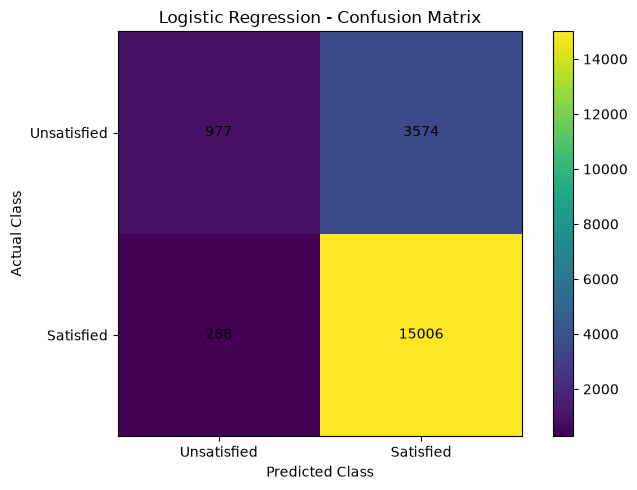

In [24]:
plt.figure(figsize=(7, 5))

plt.imshow(
    conf_matrix,
    interpolation="nearest"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    [0, 1],
    ["Unsatisfied", "Satisfied"]
)

plt.yticks(
    [0, 1],
    ["Unsatisfied", "Satisfied"]
)

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(
            j,
            i,
            conf_matrix[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

### 9.5 Classification Report

The classification report provides class-specific precision, recall, and F1 scores.

This view is particularly valuable for understanding whether the baseline model performs consistently across both satisfied and unsatisfied customers.

In [25]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Unsatisfied",
            "Satisfied"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

 Unsatisfied     0.7723    0.2147    0.3360      4551
   Satisfied     0.8076    0.9812    0.8860     15294

    accuracy                         0.8054     19845
   macro avg     0.7900    0.5979    0.6110     19845
weighted avg     0.7995    0.8054    0.7599     19845



### Observation

The classification report indicates that the baseline Logistic Regression model performs considerably better at identifying satisfied customers than dissatisfied customers.

While the model achieves strong overall accuracy and an excellent recall for the satisfied class, its recall for dissatisfied customers remains relatively low, indicating that many dissatisfied customers are incorrectly classified as satisfied.

This behavior is consistent with the class imbalance observed in the target variable and demonstrates that overall accuracy alone is insufficient for evaluating classification performance. Additional metrics such as precision, recall, F1-score, and ROC-AUC provide a more comprehensive assessment of model quality.

These findings establish a meaningful baseline for comparison with more advanced machine learning algorithms in the subsequent modeling stages.

### 9.6 Receiver Operating Characteristic (ROC) Curve

The Receiver Operating Characteristic (ROC) curve evaluates the model's ability to distinguish between satisfied and unsatisfied customers across different classification thresholds.

Unlike accuracy, which evaluates predictions at a single threshold, the ROC curve illustrates the trade-off between the True Positive Rate (Recall) and the False Positive Rate over all possible thresholds.

The Area Under the Curve (ROC-AUC) summarizes this performance into a single value. Higher ROC-AUC scores indicate stronger discrimination capability and better overall classification performance.

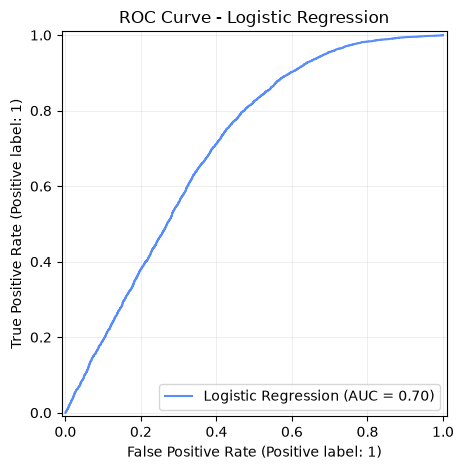

In [26]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    name="Logistic Regression"
)

plt.title("ROC Curve - Logistic Regression")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Observation

The ROC curve demonstrates that the baseline Logistic Regression model has a moderate ability to distinguish between satisfied and unsatisfied customers across different classification thresholds.

The ROC-AUC score of approximately 0.70 indicates that the model performs better than random guessing but still leaves considerable room for improvement. This result suggests that the relationship between the predictors and customer satisfaction may not be fully captured by a linear decision boundary.

More advanced machine learning algorithms will be evaluated in subsequent sections to determine whether nonlinear models can improve class discrimination and overall predictive performance.

### 9.7 Predicted Class Distribution

The distribution of predicted classes is compared with the actual target distribution to evaluate potential prediction bias.

A classifier that consistently favors the majority class may achieve high overall accuracy while performing poorly on minority-class observations. Comparing actual and predicted class frequencies provides additional insight into the model's prediction behavior beyond traditional evaluation metrics.

In [27]:
prediction_distribution = pd.DataFrame({
    "Actual Count": y_test.value_counts().sort_index(),
    "Predicted Count": pd.Series(y_pred).value_counts().sort_index()
})

prediction_distribution.index = [
    "Unsatisfied (0)",
    "Satisfied (1)"
]

prediction_distribution

,Actual Count,Predicted Count
Unsatisfied (0),4551,1265
Satisfied (1),15294,18580


In [28]:
prediction_distribution_percent = pd.DataFrame({
    "Actual (%)": (
        y_test.value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    ),
    "Predicted (%)": (
        pd.Series(y_pred)
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

prediction_distribution_percent.index = [
    "Unsatisfied (0)",
    "Satisfied (1)"
]

prediction_distribution_percent

,Actual (%),Predicted (%)
Unsatisfied (0),22.9300,6.3700
Satisfied (1),77.0700,93.6300


### Observation

The comparison between the actual and predicted class distributions reveals a noticeable prediction bias toward the majority class.

Although dissatisfied customers represent approximately 23% of the testing dataset, the Logistic Regression model predicts this class for only about 6% of observations. Consequently, many dissatisfied customers are incorrectly classified as satisfied.

This finding is consistent with the low recall observed for the dissatisfied class in the classification report and highlights the limitations of the baseline model when handling moderately imbalanced data.

Future machine learning models will be evaluated to determine whether they achieve a more balanced prediction distribution while maintaining strong overall performance.

### 9.8 Classification Error Analysis

The confusion matrix components are extracted individually to quantify the different types of prediction outcomes produced by the baseline classifier.

Analyzing True Positives, True Negatives, False Positives, and False Negatives provides a more detailed understanding of the model's strengths and weaknesses beyond aggregate evaluation metrics.

This breakdown is particularly useful for identifying whether prediction errors are concentrated within a specific customer satisfaction class.

In [29]:
tn, fp, fn, tp = conf_matrix.ravel()

error_summary = pd.DataFrame({
    "Outcome": [
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive"
    ],
    "Count": [
        tn,
        fp,
        fn,
        tp
    ]
})

error_summary

,Outcome,Count
0,True Negative,977
1,False Positive,3574
2,False Negative,288
3,True Positive,15006


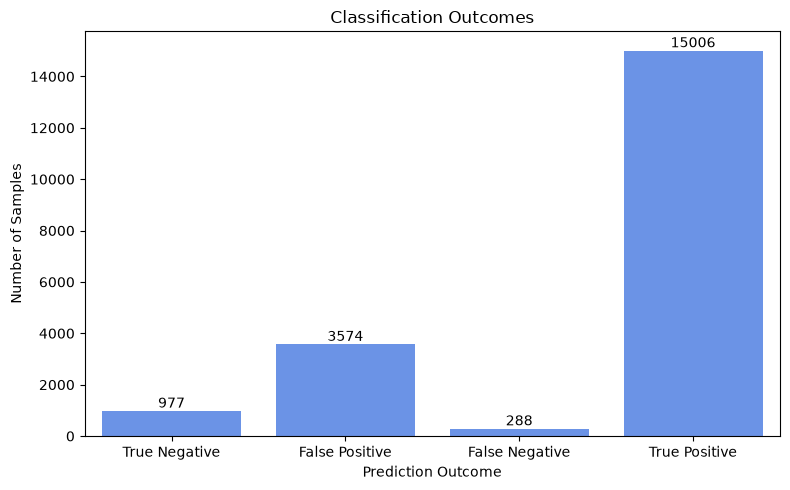

In [30]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=error_summary,
    x="Outcome",
    y="Count"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Classification Outcomes")
plt.xlabel("Prediction Outcome")
plt.ylabel("Number of Samples")

plt.tight_layout()
plt.show()

### Observation

The error analysis indicates that the baseline Logistic Regression model generates substantially more False Positives than False Negatives.

This means that a considerable number of dissatisfied customers are incorrectly classified as satisfied, while only a small number of satisfied customers are classified as dissatisfied.

Such behavior suggests that the model is biased toward predicting the majority class (Satisfied), which is expected due to the class imbalance present in the dataset.

From a business perspective, failing to identify dissatisfied customers may reduce the effectiveness of customer retention and service recovery strategies. Improving the detection of dissatisfied customers will therefore be an important objective when evaluating more advanced machine learning models.

## 10. Dummy Classifier Benchmark

A Dummy Classifier is introduced as a naive benchmark before evaluating more sophisticated machine learning algorithms.

Unlike predictive models that learn relationships between input features and the target variable, the dummy classifier follows a simple predefined strategy. In this project, the `most_frequent` strategy always predicts the majority class observed in the training data.

This benchmark establishes the minimum level of predictive performance that a meaningful machine learning model should exceed. Comparing Logistic Regression against this reference helps determine whether the model is learning useful patterns beyond the underlying class distribution.


### 10.1 Dummy Classifier Construction

The Dummy Classifier is configured using the `most_frequent` strategy, which always predicts the majority class from the training target distribution.

The model is intentionally simple and does not require feature preprocessing because it does not learn relationships from the predictor variables.


In [31]:
dummy_model = DummyClassifier(
    strategy="most_frequent",
    random_state=RANDOM_STATE
)

dummy_model

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


### 10.2 Dummy Model Training

The Dummy Classifier is fitted on the training dataset to establish a naive majority-class benchmark.

Although the input features are supplied to maintain the standard Scikit-learn estimator interface, the `most_frequent` strategy ignores their predictive information and bases its predictions exclusively on the most common target class.


In [32]:
dummy_model.fit(
    X_train,
    y_train
)

print("Dummy Classifier trained successfully.")

Dummy Classifier trained successfully.


### 10.3 Dummy Predictions

Predictions and class probabilities are generated for the held-out testing dataset.

These outputs provide a reference against which the previously trained Logistic Regression model can be evaluated.


In [33]:
y_pred_dummy = dummy_model.predict(X_test)

y_prob_dummy = dummy_model.predict_proba(X_test)[:, 1]

print("Dummy predictions generated successfully.")

Dummy predictions generated successfully.


In [34]:
pd.Series(
    y_pred_dummy,
    name="Predicted Class"
).value_counts().sort_index()

Predicted Class
1    19845
Name: count, dtype: int64

### 10.4 Dummy Benchmark Metrics

The Dummy Classifier is evaluated using the same held-out testing dataset used for the Logistic Regression baseline.

In addition to overall accuracy and ROC-AUC, class-specific metrics are reported for the unsatisfied customer class. This is particularly important because identifying potentially dissatisfied customers represents a key business objective of the predictive system.

The dummy benchmark is not expected to provide useful minority-class detection. Instead, it establishes a minimum reference point that subsequent machine learning models should meaningfully outperform.


In [35]:
dummy_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_dummy),
    "Satisfied Precision": precision_score(
        y_test,
        y_pred_dummy,
        pos_label=1,
        zero_division=0
    ),
    "Satisfied Recall": recall_score(
        y_test,
        y_pred_dummy,
        pos_label=1,
        zero_division=0
    ),
    "Satisfied F1": f1_score(
        y_test,
        y_pred_dummy,
        pos_label=1,
        zero_division=0
    ),
    "Unsatisfied Precision": precision_score(
        y_test,
        y_pred_dummy,
        pos_label=0,
        zero_division=0
    ),
    "Unsatisfied Recall": recall_score(
        y_test,
        y_pred_dummy,
        pos_label=0,
        zero_division=0
    ),
    "Unsatisfied F1": f1_score(
        y_test,
        y_pred_dummy,
        pos_label=0,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        y_prob_dummy
    )
}

dummy_metrics_df = pd.DataFrame(
    dummy_metrics.items(),
    columns=["Metric", "Score"]
).set_index("Metric")

dummy_metrics_df

,Score
Metric,
Accuracy,0.7707
Satisfied Precision,0.7707
Satisfied Recall,1.0000
Satisfied F1,0.8705
Unsatisfied Precision,0.0000
Unsatisfied Recall,0.0000
Unsatisfied F1,0.0000
ROC-AUC,0.5000


### 10.5 Logistic Regression vs Dummy Benchmark

The Logistic Regression model is compared directly with the naive Dummy Classifier to determine whether the learned model provides meaningful predictive value beyond the majority-class distribution.

Because overall accuracy can be misleading in imbalanced classification problems, the comparison includes both probability-based discrimination performance and metrics specifically focused on the unsatisfied customer class.


In [36]:
benchmark_comparison = pd.DataFrame({
    "Dummy Classifier": {
        "Accuracy": accuracy_score(y_test, y_pred_dummy),
        "ROC-AUC": roc_auc_score(y_test, y_prob_dummy),
        "Unsatisfied Precision": precision_score(
            y_test, y_pred_dummy,
            pos_label=0,
            zero_division=0
        ),
        "Unsatisfied Recall": recall_score(
            y_test, y_pred_dummy,
            pos_label=0,
            zero_division=0
        ),
        "Unsatisfied F1": f1_score(
            y_test, y_pred_dummy,
            pos_label=0,
            zero_division=0
        )
    },

    "Logistic Regression": {
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Unsatisfied Precision": precision_score(
            y_test, y_pred,
            pos_label=0
        ),
        "Unsatisfied Recall": recall_score(
            y_test, y_pred,
            pos_label=0
        ),
        "Unsatisfied F1": f1_score(
            y_test, y_pred,
            pos_label=0
        )
    }
}).T

benchmark_comparison.round(4)

,Accuracy,ROC-AUC,Unsatisfied Precision,Unsatisfied Recall,Unsatisfied F1
Dummy Classifier,0.7707,0.5000,0.0000,0.0000,0.0000
Logistic Regression,0.8054,0.7017,0.7723,0.2147,0.3360


### Observation

The benchmark comparison demonstrates why accuracy alone is insufficient for evaluating this classification problem.

The Dummy Classifier achieves an accuracy of **77.07%**, which may initially appear relatively strong. However, this performance is entirely driven by the underlying class imbalance. Because the majority of observations belong to the satisfied customer class, the dummy model predicts every observation as satisfied. Consequently, it achieves **0.00 precision, 0.00 recall, and 0.00 F1-score for the unsatisfied customer class**, while its ROC-AUC remains at **0.50**, indicating no discriminative ability beyond random ranking.

The Logistic Regression model provides a meaningful improvement over this naive benchmark. Accuracy increases from **77.07% to 80.54%**, while ROC-AUC improves substantially from **0.50 to 0.7017**, demonstrating that the model has learned predictive relationships between the engineered features and customer satisfaction.

More importantly, Logistic Regression begins to identify the minority unsatisfied class, achieving an **unsatisfied precision of 77.23%**. This indicates that when the model predicts a customer as unsatisfied, the prediction is frequently correct.

However, the **unsatisfied recall of only 21.47%** reveals an important limitation. The model still fails to identify the majority of genuinely unsatisfied customers. The resulting unsatisfied-class F1-score of **0.3360** confirms that the baseline model does not yet provide a sufficiently balanced solution for minority-class detection.

From a customer intelligence perspective, this limitation is particularly important because failing to identify dissatisfied customers may prevent the business from recognizing customers who require intervention, service recovery, or retention actions.

Therefore, Logistic Regression clearly outperforms the naive benchmark and establishes that the engineered feature set contains useful predictive information. Nevertheless, its limited minority-class recall motivates the evaluation of more flexible nonlinear models and, subsequently, class-imbalance mitigation and model optimization techniques.


# 11. Decision Tree Classifier

A Decision Tree classifier is evaluated as the first nonlinear alternative to the Logistic Regression baseline.

Unlike Logistic Regression, Decision Trees can capture nonlinear relationships and interactions between predictive variables without requiring an explicitly linear decision boundary.

The model is trained using the same preprocessing pipeline and the same training and test datasets used for the previous models. This ensures that differences in performance are attributable to the modeling algorithm rather than changes in preprocessing or data partitioning.

The initial Decision Tree is trained using default model complexity settings with a fixed random state. Hyperparameter optimization will be performed in a later stage of the modeling workflow.

## 11.1 Decision Tree Pipeline Construction

A dedicated machine learning pipeline is constructed for the Decision Tree classifier using the previously defined preprocessing framework.

The pipeline combines the `ColumnTransformer` preprocessing stage with a `DecisionTreeClassifier`, ensuring that numerical and categorical features undergo the same transformations used throughout the modeling workflow.

Using a unified pipeline provides several advantages:

- preprocessing and model training are executed as a single reproducible workflow,
- transformations learned from the training data are consistently applied to new observations,
- the risk of inconsistent preprocessing between training and inference is reduced,
- and the resulting pipeline can later be evaluated, tuned, compared, and serialized as a complete modeling object.

The initial Decision Tree is configured with `random_state=42` to ensure reproducibility. Model complexity is intentionally left untuned at this stage so that the default Decision Tree can serve as an unbiased initial benchmark before hyperparameter optimization.

In [37]:
decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        DecisionTreeClassifier(
            random_state=42
        )
    )
])

decision_tree_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

## 11.2 Model Training

The Decision Tree pipeline is trained using the training dataset.

Because preprocessing and classification are encapsulated within the same pipeline, all numerical scaling and categorical encoding operations are learned exclusively from the training data before the classifier is fitted.

Training the Decision Tree under the same preprocessing framework used for Logistic Regression ensures a consistent and fair comparison between the models.

In [38]:
decision_tree_pipeline.fit(
    X_train,
    y_train
)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


## 11.3 Test Set Predictions

The trained Decision Tree model is evaluated on the unseen test dataset.

Both class predictions and class probabilities are generated. Class predictions are required for classification metrics such as accuracy, precision, recall, and F1-score, while predicted probabilities are used to calculate ROC-AUC.

In [39]:
y_pred_dt = decision_tree_pipeline.predict(X_test)

y_prob_dt = decision_tree_pipeline.predict_proba(X_test)[:, 1]

print("Decision Tree predictions generated successfully.")
print("Number of predictions:", len(y_pred_dt))

Decision Tree predictions generated successfully.
Number of predictions: 19845


## 11.4 Decision Tree Performance Evaluation

The Decision Tree is evaluated using the same performance metrics used for the previous benchmark models to maintain consistency throughout the model comparison process.

In addition to overall accuracy and ROC-AUC, special attention is given to precision, recall, and F1-score for the unsatisfied customer class.

This class-specific evaluation is particularly important because the primary modeling challenge is not only achieving strong overall predictive performance, but also improving the identification of customers who are likely to be unsatisfied.

In [40]:
decision_tree_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        y_pred_dt
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        y_prob_dt
    ),
    "Unsatisfied Precision": precision_score(
        y_test,
        y_pred_dt,
        pos_label=0
    ),
    "Unsatisfied Recall": recall_score(
        y_test,
        y_pred_dt,
        pos_label=0
    ),
    "Unsatisfied F1": f1_score(
        y_test,
        y_pred_dt,
        pos_label=0
    )
}

decision_tree_metrics_df = (
    pd.DataFrame(
        decision_tree_metrics.items(),
        columns=["Metric", "Score"]
    )
    .set_index("Metric")
)

decision_tree_metrics_df.round(4)

,Score
Metric,
Accuracy,0.7159
ROC-AUC,0.6074
Unsatisfied Precision,0.3866
Unsatisfied Recall,0.4072
Unsatisfied F1,0.3966


### Observation

The initial Decision Tree exhibits a substantially different classification behavior compared with the Logistic Regression baseline.

Overall accuracy decreases from **80.54%** for Logistic Regression to **71.59%** for the Decision Tree, while ROC-AUC decreases from **0.7017** to **0.6074**. These results indicate that the untuned Decision Tree provides weaker overall discrimination on the unseen test dataset.

However, the model demonstrates a notable improvement in detecting the minority unsatisfied customer class. Unsatisfied recall increases from **21.47%** under Logistic Regression to **40.72%** under the Decision Tree. The corresponding unsatisfied F1-score also improves from **0.3360** to **0.3966**.

This improvement comes at a considerable cost in precision. Unsatisfied precision decreases from **77.23%** to **38.66%**, indicating that the Decision Tree identifies more genuinely unsatisfied customers but also generates substantially more false unsatisfied predictions.

The results therefore reveal an important precision-recall trade-off. Logistic Regression is more conservative when predicting customer dissatisfaction, whereas the Decision Tree is more sensitive to the unsatisfied class but considerably less precise.

The relatively weak overall performance of the default Decision Tree may also indicate excessive model complexity and potential overfitting. This hypothesis will later be examined through cross-validation and hyperparameter optimization.

At this stage, neither model should be selected as the final solution. Additional models and validation procedures are required before determining the most appropriate classifier for the customer intelligence system.

## 11.5 Confusion Matrix

The confusion matrix is used to examine the distribution of correct and incorrect predictions produced by the Decision Tree classifier.

This analysis is particularly important because the Decision Tree demonstrated a higher recall for unsatisfied customers but lower precision compared with Logistic Regression.

By separating the predictions into True Negatives, False Positives, False Negatives, and True Positives, the confusion matrix provides a more detailed explanation of this precision-recall trade-off.

In [41]:
dt_conf_matrix = confusion_matrix(
    y_test,
    y_pred_dt
)

dt_confusion_matrix_df = pd.DataFrame(
    dt_conf_matrix,
    index=[
        "Actual Unsatisfied (0)",
        "Actual Satisfied (1)"
    ],
    columns=[
        "Predicted Unsatisfied (0)",
        "Predicted Satisfied (1)"
    ]
)

dt_confusion_matrix_df

,Predicted Unsatisfied (0),Predicted Satisfied (1)
Actual Unsatisfied (0),1853,2698
Actual Satisfied (1),2940,12354


## 11.6 Confusion Matrix Visualization

A visual representation of the Decision Tree confusion matrix is created to improve interpretability.

The visualization makes it easier to compare correctly classified observations with the different types of classification errors and provides additional context for the model's increased sensitivity toward the unsatisfied customer class.

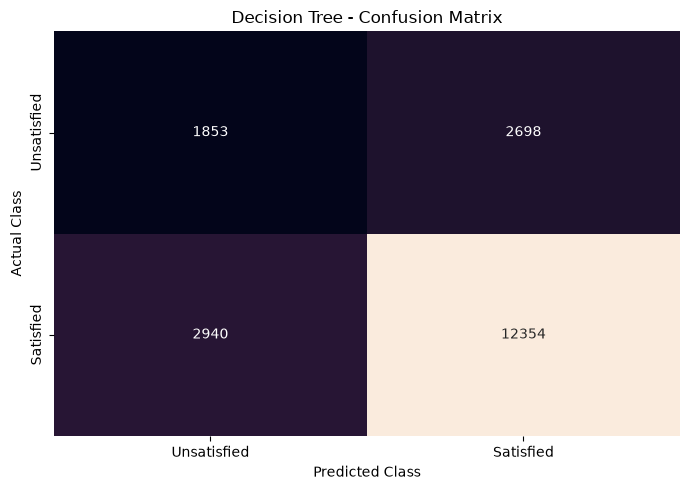

In [42]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    dt_conf_matrix,
    annot=True,
    fmt="d",
    cbar=False,
    xticklabels=[
        "Unsatisfied",
        "Satisfied"
    ],
    yticklabels=[
        "Unsatisfied",
        "Satisfied"
    ]
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

## 11.7 Classification Report

The classification report provides a class-level evaluation of the Decision Tree classifier using precision, recall, and F1-score.

This analysis is especially important for the current customer satisfaction prediction problem because the target distribution is imbalanced. Evaluating each class separately helps determine whether the model performs consistently across satisfied and unsatisfied customers rather than relying only on overall accuracy.

Particular attention is given to the Unsatisfied class, since identifying potentially dissatisfied customers is an important customer intelligence objective.

In [43]:
print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=[
            "Unsatisfied",
            "Satisfied"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

 Unsatisfied     0.3866    0.4072    0.3966      4551
   Satisfied     0.8208    0.8078    0.8142     15294

    accuracy                         0.7159     19845
   macro avg     0.6037    0.6075    0.6054     19845
weighted avg     0.7212    0.7159    0.7184     19845



### Observation

The classification report reveals a substantial difference in predictive performance between the two customer satisfaction classes.

For the **Satisfied** class, the Decision Tree achieves a precision of **0.8208**, recall of **0.8078**, and F1-score of **0.8142**, indicating relatively strong performance for the majority class.

For the **Unsatisfied** class, performance is considerably weaker. The model achieves a precision of **0.3866**, recall of **0.4072**, and F1-score of **0.3966**. Although the Decision Tree identifies a larger proportion of unsatisfied customers than the baseline Logistic Regression model, this improvement in recall is accompanied by a substantial reduction in precision.

The overall accuracy of **0.7159** is also lower than the Logistic Regression baseline accuracy of **0.8054**. However, accuracy alone is not sufficient for evaluating this problem because the target variable is imbalanced and the business objective includes identifying dissatisfied customers.

The macro-average F1-score of **0.6054**, compared with the weighted-average F1-score of **0.7184**, further demonstrates that predictive performance is not balanced across the two classes.

These results suggest that the default Decision Tree provides greater sensitivity toward the minority Unsatisfied class, but at the cost of overall predictive performance and substantially more classification errors. Further model comparison, class-imbalance handling, and hyperparameter optimization will therefore be required before selecting the final model.

## 11.8 ROC Curve Analysis

The Receiver Operating Characteristic (ROC) curve is used to evaluate the Decision Tree classifier across different classification thresholds.

Unlike accuracy, the ROC curve evaluates the relationship between the True Positive Rate and False Positive Rate over a range of decision thresholds. The Area Under the ROC Curve (ROC-AUC) provides a threshold-independent measure of the model's ability to discriminate between the two target classes.

A higher ROC-AUC indicates stronger discriminatory capability, while a value close to 0.50 represents performance similar to random classification.

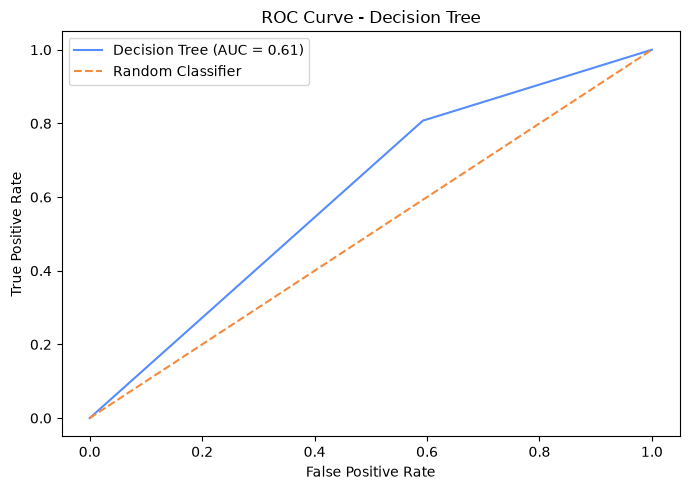

In [44]:
fpr_dt, tpr_dt, thresholds_dt = roc_curve(
    y_test,
    y_prob_dt
)

roc_auc_dt = roc_auc_score(
    y_test,
    y_prob_dt
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree (AUC = {roc_auc_dt:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()

plt.tight_layout()
plt.show()

### Observation

The Decision Tree achieves a ROC-AUC score of approximately **0.61**, indicating only moderate discriminatory ability between satisfied and unsatisfied customers.

Although the model performs better than random classification, represented by a ROC-AUC of 0.50, its discrimination capability is noticeably weaker than the Logistic Regression baseline, which achieved a ROC-AUC of approximately **0.70**.

This result is consistent with the previous evaluation metrics. The Decision Tree improves recall for the unsatisfied customer class, but this improvement is accompanied by substantially lower precision, lower overall accuracy, and weaker probability-based discrimination.

The relatively low ROC-AUC suggests that the default Decision Tree does not generalize sufficiently well to unseen observations. Its unrestricted structure may also contribute to high variance and overfitting, which will be investigated later through cross-validation and hyperparameter optimization.

Overall, the Decision Tree provides useful evidence that nonlinear decision boundaries can improve minority-class sensitivity, but the untuned model does not currently outperform Logistic Regression as a complete predictive solution.


# 12. Random Forest Classifier

Random Forest is introduced as the third supervised learning algorithm in the modeling workflow.

Unlike a single Decision Tree, Random Forest is an ensemble learning method that combines predictions from multiple decision trees trained on different bootstrap samples and randomized subsets of features. This approach is designed to reduce the variance associated with individual decision trees and generally provides more stable predictions on unseen observations.

The objective of this section is to determine whether an ensemble-based nonlinear model can improve predictive performance while maintaining stronger generalization than the standalone Decision Tree.

The initial Random Forest model is evaluated using default modeling assumptions before class-imbalance strategies and hyperparameter optimization are introduced in later sections.

## 12.1 Random Forest Pipeline Construction

A dedicated machine learning pipeline is constructed for the Random Forest classifier using the same preprocessing framework applied to the previous models.

Maintaining a consistent preprocessing pipeline ensures that differences in model performance are primarily attributable to the learning algorithms rather than inconsistencies in data transformation.

The initial Random Forest classifier is configured with `random_state=42` to ensure reproducibility and `n_jobs=-1` to allow parallel tree construction across available CPU cores.

At this stage, the model is intentionally left untuned. This provides an initial benchmark that can later be compared with cross-validated and hyperparameter-optimized versions of the model.

In [45]:
random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        )
    )
])

random_forest_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

## 12.2 Random Forest Model Training

The Random Forest pipeline is trained using the training dataset.

During this process, the preprocessing transformations are learned exclusively from the training data and subsequently applied before the Random Forest classifier is fitted.

Because Random Forest constructs multiple decision trees, training is computationally more expensive than fitting a single Decision Tree or Logistic Regression model. Parallel processing is therefore enabled to improve computational efficiency.

The test dataset remains completely unseen during training and will only be used for final evaluation of the fitted model.

In [46]:
random_forest_pipeline.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## 12.3 Prediction Generation

Predictions are generated on the unseen test dataset using the trained Random Forest pipeline.

Two forms of model output are obtained:

- **Class predictions** indicate whether each observation is classified as Unsatisfied (0) or Satisfied (1).
- **Prediction probabilities** represent the estimated probability that each observation belongs to the positive Satisfied class.

The class predictions will be used to calculate classification metrics and construct the confusion matrix, while the predicted probabilities will later be used for ROC-AUC evaluation and ROC curve analysis.

Using the same test dataset and evaluation framework as the previous models ensures that the Random Forest results remain directly comparable with the Logistic Regression and Decision Tree benchmarks.

In [47]:
y_pred_rf = random_forest_pipeline.predict(X_test)

y_prob_rf = random_forest_pipeline.predict_proba(
    X_test
)[:, 1]

print("Random Forest predictions generated successfully.")
print(f"Number of predictions: {len(y_pred_rf):,}")
rf_prediction_distribution = pd.Series(
    y_pred_rf
).value_counts().sort_index()

rf_prediction_distribution.index = [
    "Unsatisfied (0)",
    "Satisfied (1)"
]

rf_prediction_distribution

Random Forest predictions generated successfully.
Number of predictions: 19,845


Unsatisfied (0)     1900
Satisfied (1)      17945
Name: count, dtype: int64

## 12.4 Random Forest Performance Metrics

The predictive performance of the Random Forest classifier is evaluated on the unseen test dataset using the same metrics applied to the previous baseline models.

Because the target variable is imbalanced, overall accuracy alone is not sufficient to assess model quality. Therefore, the evaluation includes ROC-AUC together with class-specific precision, recall, and F1-score for the Unsatisfied customer class.

Using an identical evaluation framework ensures a fair comparison between Random Forest, Decision Tree, and Logistic Regression before subsequent cross-validation and hyperparameter optimization.

In [48]:
random_forest_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        y_pred_rf
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        y_prob_rf
    ),
    "Unsatisfied Precision": precision_score(
        y_test,
        y_pred_rf,
        pos_label=0
    ),
    "Unsatisfied Recall": recall_score(
        y_test,
        y_pred_rf,
        pos_label=0
    ),
    "Unsatisfied F1": f1_score(
        y_test,
        y_pred_rf,
        pos_label=0
    )
}

random_forest_metrics_df = (
    pd.DataFrame(
        random_forest_metrics.items(),
        columns=["Metric", "Score"]
    )
    .set_index("Metric")
)

random_forest_metrics_df.round(4)

,Score
Metric,
Accuracy,0.8241
ROC-AUC,0.7262
Unsatisfied Precision,0.7789
Unsatisfied Recall,0.3252
Unsatisfied F1,0.4588


### Observation

The initial Random Forest model demonstrates the strongest overall performance among the supervised learning models evaluated so far.

The model achieves an accuracy of **0.8241** and a ROC-AUC of **0.7262**, outperforming both Logistic Regression and the standalone Decision Tree on overall predictive performance and probability-based class discrimination.

For the Unsatisfied customer class, Random Forest achieves a precision of **0.7789**, indicating that predictions of customer dissatisfaction are frequently correct. The Unsatisfied recall of **0.3252** also represents an improvement over Logistic Regression, although it remains below the recall achieved by the standalone Decision Tree.

Importantly, the Unsatisfied F1-score increases to **0.4588**, which is the highest minority-class F1-score observed so far. This suggests that Random Forest provides a more favorable balance between precision and recall when identifying dissatisfied customers.

These results demonstrate the benefit of combining multiple decision trees into an ensemble. Compared with a single Decision Tree, Random Forest substantially improves generalization while preserving greater sensitivity to the Unsatisfied class than Logistic Regression.

At this stage, Random Forest represents the strongest overall candidate. However, final model selection should not yet be performed, since cross-validation, class-imbalance analysis, and hyperparameter optimization are still required.

## 12.5 Confusion Matrix

The confusion matrix is used to examine how the Random Forest classifier distributes correct and incorrect predictions across the two customer satisfaction classes.

This analysis provides additional context for the model's precision and recall values and helps identify the specific types of classification errors produced by the ensemble model.

In [49]:
rf_conf_matrix = confusion_matrix(
    y_test,
    y_pred_rf
)

rf_confusion_matrix_df = pd.DataFrame(
    rf_conf_matrix,
    index=[
        "Actual Unsatisfied (0)",
        "Actual Satisfied (1)"
    ],
    columns=[
        "Predicted Unsatisfied (0)",
        "Predicted Satisfied (1)"
    ]
)

rf_confusion_matrix_df

,Predicted Unsatisfied (0),Predicted Satisfied (1)
Actual Unsatisfied (0),1480,3071
Actual Satisfied (1),420,14874


## 12.6 Confusion Matrix Visualization

The Random Forest confusion matrix is visualized to provide a clearer representation of correct and incorrect classifications across the two target classes.

The visualization is particularly useful for examining the model's behavior toward the minority Unsatisfied class and identifying the imbalance between correctly detected dissatisfied customers and those incorrectly classified as Satisfied.

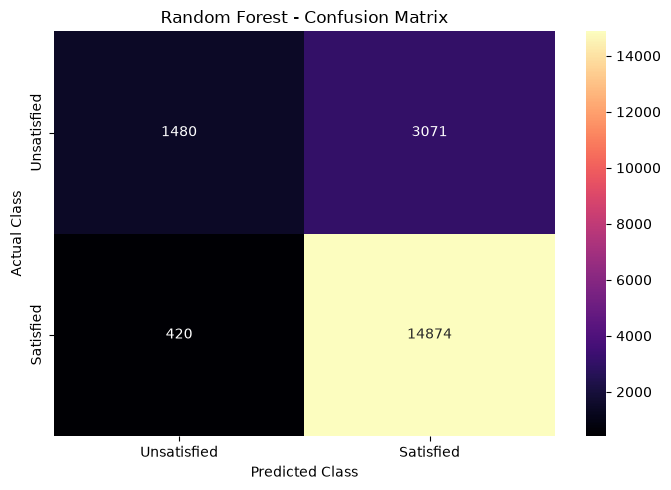

In [50]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    rf_conf_matrix,
    annot=True,
    fmt="d",
    cmap="magma",
    xticklabels=[
        "Unsatisfied",
        "Satisfied"
    ],
    yticklabels=[
        "Unsatisfied",
        "Satisfied"
    ]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

### Observation

The confusion matrix confirms that the Random Forest classifier performs particularly well on the majority Satisfied class, correctly identifying **14,874** satisfied customers.

For the minority Unsatisfied class, **1,480** observations are correctly identified, while **3,071** dissatisfied customers are incorrectly classified as Satisfied. In comparison, only **420** satisfied customers are incorrectly classified as Unsatisfied.

This error distribution indicates that the model remains biased toward the majority Satisfied class. Although Random Forest improves minority-class detection compared with Logistic Regression, a substantial proportion of dissatisfied customers is still missed.

This behavior reinforces the need for the class-imbalance analysis planned later in the modeling workflow.

## 12.7 Classification Report

The classification report provides a class-level evaluation of the Random Forest classifier using precision, recall, F1-score, and support.

This analysis is particularly important because the target variable is imbalanced. Evaluating both classes separately provides a more complete understanding of model performance than relying solely on overall accuracy.

Particular attention is given to the Unsatisfied class, since identifying dissatisfied customers represents an important objective of the customer intelligence system.

In [51]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "Unsatisfied",
            "Satisfied"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

 Unsatisfied     0.7789    0.3252    0.4588      4551
   Satisfied     0.8289    0.9725    0.8950     15294

    accuracy                         0.8241     19845
   macro avg     0.8039    0.6489    0.6769     19845
weighted avg     0.8174    0.8241    0.7950     19845



### Observation

The classification report confirms that the Random Forest classifier performs substantially better on the majority Satisfied class than on the minority Unsatisfied class.

For Satisfied customers, the model achieves a recall of **0.9725** and an F1-score of **0.8950**, demonstrating strong predictive performance for the majority class.

For Unsatisfied customers, precision reaches **0.7789**, indicating that when the model predicts dissatisfaction, the prediction is generally reliable. However, recall remains considerably lower at **0.3252**, meaning that a substantial proportion of dissatisfied customers are still classified as Satisfied. The resulting Unsatisfied F1-score is **0.4588**.

The difference between the macro-average F1-score (**0.6769**) and weighted-average F1-score (**0.7950**) further reflects the influence of class imbalance on overall model performance.

Although Random Forest currently provides the strongest overall performance among the evaluated models, the class-level results indicate that minority-class detection can potentially be improved. This issue will be examined systematically during the later class-imbalance analysis and model optimization stages.

## 12.8 ROC Curve Analysis

The Receiver Operating Characteristic (ROC) curve is used to evaluate the Random Forest classifier across different classification thresholds.

The ROC curve illustrates the trade-off between the True Positive Rate and False Positive Rate, while the Area Under the ROC Curve (ROC-AUC) provides a threshold-independent measure of the model's ability to discriminate between the two target classes.

This analysis allows the Random Forest model to be evaluated beyond the default classification threshold and provides a directly comparable discrimination metric for the previously evaluated classifiers.

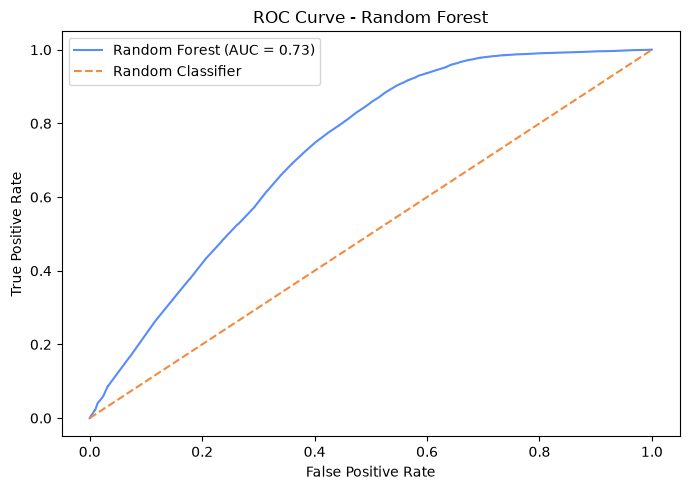

In [52]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(
    y_test,
    y_prob_rf
)

roc_auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_rf:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.tight_layout()
plt.show()

### Observation

The ROC curve shows that the Random Forest classifier achieves a ROC-AUC of approximately **0.73**, indicating a moderate ability to discriminate between Satisfied and Unsatisfied customers across different classification thresholds.

The ROC curve remains consistently above the random-classifier baseline, confirming that the model captures meaningful predictive patterns rather than relying on chance-level discrimination.

Compared with the previously evaluated Logistic Regression and Decision Tree models, the Random Forest provides stronger overall discriminatory performance. However, the earlier class-level analysis showed that the model still has limited recall for the minority Unsatisfied class.

Therefore, while Random Forest currently represents the strongest initial candidate, further evaluation through cross-validation, class-imbalance analysis, and hyperparameter tuning is required before selecting the final model.

# 13. Initial Model Comparison

## 13.1 Initial Model Performance Comparison

The baseline and initial machine learning models are compared using a common set of evaluation metrics to provide a consistent assessment of predictive performance.

The comparison includes:

- Dummy Classifier
- Logistic Regression
- Decision Tree
- Random Forest

Because the target variable is imbalanced, model selection should not rely exclusively on overall accuracy. In addition to Accuracy and ROC-AUC, particular attention is given to Precision, Recall, and F1-score for the minority **Unsatisfied** class.

At this stage, the objective is not to select the final production model, but to identify the strongest candidates for subsequent cross-validation, class-imbalance analysis, and hyperparameter optimization.

In [53]:
initial_model_comparison = pd.DataFrame({
    "Dummy Classifier": {
        "Accuracy": dummy_metrics["Accuracy"],
        "ROC-AUC": dummy_metrics["ROC-AUC"],
        "Unsatisfied Precision": dummy_metrics["Unsatisfied Precision"],
        "Unsatisfied Recall": dummy_metrics["Unsatisfied Recall"],
        "Unsatisfied F1": dummy_metrics["Unsatisfied F1"]
    },

    "Logistic Regression": {
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Unsatisfied Precision": precision_score(
            y_test, y_pred, pos_label=0
        ),
        "Unsatisfied Recall": recall_score(
            y_test, y_pred, pos_label=0
        ),
        "Unsatisfied F1": f1_score(
            y_test, y_pred, pos_label=0
        )
    },

    "Decision Tree": {
        "Accuracy": accuracy_score(y_test, y_pred_dt),
        "ROC-AUC": roc_auc_score(y_test, y_prob_dt),
        "Unsatisfied Precision": precision_score(
            y_test, y_pred_dt, pos_label=0
        ),
        "Unsatisfied Recall": recall_score(
            y_test, y_pred_dt, pos_label=0
        ),
        "Unsatisfied F1": f1_score(
            y_test, y_pred_dt, pos_label=0
        )
    },

    "Random Forest": {
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "ROC-AUC": roc_auc_score(y_test, y_prob_rf),
        "Unsatisfied Precision": precision_score(
            y_test, y_pred_rf, pos_label=0
        ),
        "Unsatisfied Recall": recall_score(
            y_test, y_pred_rf, pos_label=0
        ),
        "Unsatisfied F1": f1_score(
            y_test, y_pred_rf, pos_label=0
        )
    }
}).T

initial_model_comparison.round(4)

,Accuracy,ROC-AUC,Unsatisfied Precision,Unsatisfied Recall,Unsatisfied F1
Dummy Classifier,0.7707,0.5000,0.0000,0.0000,0.0000
Logistic Regression,0.8054,0.7017,0.7723,0.2147,0.3360
Decision Tree,0.7159,0.6074,0.3866,0.4072,0.3966
Random Forest,0.8241,0.7262,0.7789,0.3252,0.4588


### Observation

The initial model comparison reveals clear differences in the predictive behavior of the evaluated classifiers.

The Dummy Classifier achieves an accuracy of **0.7707**, but its ROC-AUC of **0.5000** and zero scores for all Unsatisfied-class metrics confirm that it simply predicts the majority class and provides no meaningful ability to identify dissatisfied customers.

Logistic Regression improves overall performance, reaching an accuracy of **0.8054** and a ROC-AUC of **0.7017**. However, its Unsatisfied Recall remains relatively low at **0.2147**, indicating that a substantial proportion of dissatisfied customers are still missed.

The Decision Tree produces the highest Unsatisfied Recall among the initial models at **0.4072**, but this improvement comes at the cost of considerably lower overall accuracy (**0.7159**) and ROC-AUC (**0.6074**).

Random Forest provides the strongest overall initial performance, achieving the highest Accuracy (**0.8241**), ROC-AUC (**0.7262**), Unsatisfied Precision (**0.7789**), and Unsatisfied F1-score (**0.4588**). Its Unsatisfied Recall (**0.3252**) also represents a substantial improvement over Logistic Regression, although it remains below the Decision Tree.

Overall, Random Forest emerges as the strongest initial candidate. However, no final model is selected at this stage. Cross-validation, class-imbalance analysis, and hyperparameter optimization will be used to determine whether its performance is stable and whether minority-class detection can be further improved without excessively reducing overall predictive accuracy.

## 13.2 Comparative Performance Visualization

To complement the numerical comparison, the initial model results are visualized across the key evaluation metrics.

This visualization enables a direct comparison of model performance in terms of overall predictive accuracy, class discrimination, and the ability to identify the minority Unsatisfied customer class.

Particular attention is given to **Unsatisfied Recall** and **Unsatisfied F1-score**, since strong overall accuracy alone may conceal weak performance on the minority class.

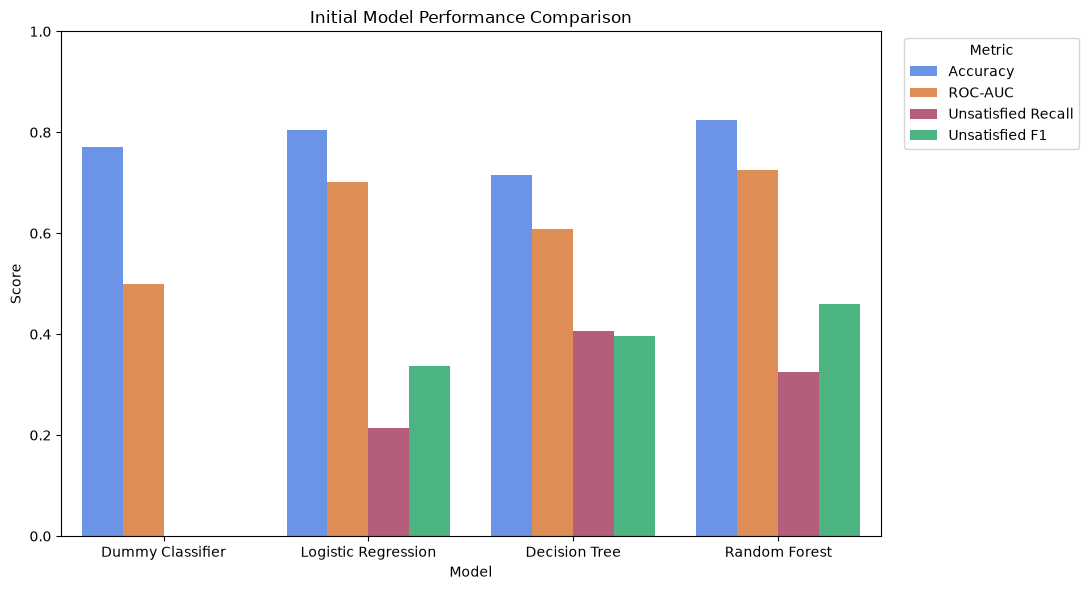

In [54]:
comparison_plot_df = (
    initial_model_comparison[
        [
            "Accuracy",
            "ROC-AUC",
            "Unsatisfied Recall",
            "Unsatisfied F1"
        ]
    ]
    .reset_index()
    .rename(columns={"index": "Model"})
    .melt(
        id_vars="Model",
        var_name="Metric",
        value_name="Score"
    )
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=comparison_plot_df,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Initial Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Observation

The comparative visualization highlights the trade-offs between overall predictive performance and minority-class detection across the initial models.

The Dummy Classifier achieves relatively high accuracy because of the imbalanced target distribution, but its zero Unsatisfied Recall and F1-score demonstrate that it provides no meaningful capability for identifying dissatisfied customers.

Logistic Regression improves both overall discrimination and minority-class detection, although its Unsatisfied Recall remains limited.

The Decision Tree achieves the highest Unsatisfied Recall among the initial models, indicating greater sensitivity to dissatisfied customers. However, this improvement is accompanied by substantially lower Accuracy and ROC-AUC, suggesting weaker overall generalization.

Random Forest provides the strongest overall balance across the evaluated metrics. It achieves the highest Accuracy, ROC-AUC, and Unsatisfied F1-score while maintaining substantially better Unsatisfied Recall than Logistic Regression.

These results support Random Forest as the strongest initial candidate, while also demonstrating that further optimization should focus on improving minority-class recall without sacrificing excessive overall predictive performance.

# 14. Cross-Validation

## 14.1 Cross-Validation Strategy

The initial model comparison was based on a single train-test split. Although this provides a useful first evaluation, model performance may vary depending on the specific observations included in the training and test subsets.

To obtain a more robust estimate of generalization performance, **5-fold Stratified Cross-Validation** is applied to the training data.

Stratification preserves the class distribution within each fold, which is particularly important because the target variable is imbalanced.

The following models are evaluated:

- Logistic Regression
- Decision Tree
- Random Forest

Multiple evaluation metrics are considered rather than relying exclusively on accuracy. Particular attention is given to ROC-AUC and the precision, recall, and F1-score of the minority **Unsatisfied** class.

The held-out test set is not used during cross-validation and remains reserved for later model evaluation.

In [55]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
cv_search = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

print("Cross-validation strategy:")
print(cv)

Cross-validation strategy:
StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [56]:
from sklearn.model_selection import train_test_split

X_search, _, y_search, _ = train_test_split(
    X_train, y_train,
    train_size=20000,
    stratify=y_train,
    random_state=42
)

print("X_search:", X_search.shape)

X_search: (20000, 27)


## 14.2 Cross-Validation Scoring Framework

A custom scoring framework is defined to evaluate model performance consistently across all cross-validation folds.

In addition to overall Accuracy and ROC-AUC, class-specific Precision, Recall, and F1-score are calculated for the minority **Unsatisfied (0)** class.

Custom scorers are required because scikit-learn's default binary classification scorers treat class `1` as the positive class, whereas the primary minority class of interest in this project is **Unsatisfied (0)**.

This scoring framework therefore ensures that cross-validation directly measures the models' ability to identify dissatisfied customers while still monitoring overall predictive performance.

In [57]:
unsatisfied_precision_scorer = make_scorer(
    precision_score,
    pos_label=0,
    zero_division=0
)

unsatisfied_recall_scorer = make_scorer(
    recall_score,
    pos_label=0,
    zero_division=0
)

unsatisfied_f1_scorer = make_scorer(
    f1_score,
    pos_label=0,
    zero_division=0
)

cv_scoring = {
    "accuracy": "accuracy",
    "roc_auc": "roc_auc",
    "unsatisfied_precision": unsatisfied_precision_scorer,
    "unsatisfied_recall": unsatisfied_recall_scorer,
    "unsatisfied_f1": unsatisfied_f1_scorer
}

cv_scoring

{'accuracy': 'accuracy',
 'roc_auc': 'roc_auc',
 'unsatisfied_precision': make_scorer(precision_score, response_method='predict', pos_label=0, zero_division=0),
 'unsatisfied_recall': make_scorer(recall_score, response_method='predict', pos_label=0, zero_division=0),
 'unsatisfied_f1': make_scorer(f1_score, response_method='predict', pos_label=0, zero_division=0)}

## 14.3 Logistic Regression Cross-Validation

The Logistic Regression pipeline is evaluated using the previously defined 5-fold Stratified Cross-Validation strategy.

Cross-validation is performed exclusively on the training dataset, ensuring that the held-out test set remains untouched.

For each fold, Accuracy, ROC-AUC, Unsatisfied Precision, Unsatisfied Recall, and Unsatisfied F1-score are calculated. The mean and standard deviation of these scores are then summarized to assess both predictive performance and model stability across different validation subsets.

In [58]:
logistic_cv_results = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=cv_scoring,
    n_jobs=-1,
    return_train_score=False
)

logistic_cv_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "ROC-AUC",
        "Unsatisfied Precision",
        "Unsatisfied Recall",
        "Unsatisfied F1"
    ],
    "Mean": [
        logistic_cv_results["test_accuracy"].mean(),
        logistic_cv_results["test_roc_auc"].mean(),
        logistic_cv_results["test_unsatisfied_precision"].mean(),
        logistic_cv_results["test_unsatisfied_recall"].mean(),
        logistic_cv_results["test_unsatisfied_f1"].mean()
    ],
    "Std": [
        logistic_cv_results["test_accuracy"].std(),
        logistic_cv_results["test_roc_auc"].std(),
        logistic_cv_results["test_unsatisfied_precision"].std(),
        logistic_cv_results["test_unsatisfied_recall"].std(),
        logistic_cv_results["test_unsatisfied_f1"].std()
    ]
}).set_index("Metric")

logistic_cv_summary.round(4)

,Mean,Std
Metric,,
Accuracy,0.8061,0.0008
ROC-AUC,0.7062,0.0019
Unsatisfied Precision,0.7826,0.0098
Unsatisfied Recall,0.2138,0.0063
Unsatisfied F1,0.3358,0.0072


### Observation

The 5-fold Stratified Cross-Validation results demonstrate that Logistic Regression provides highly stable performance across different validation subsets.

The model achieves a mean Accuracy of **0.8061** and a mean ROC-AUC of **0.7062**, both with very low standard deviations. This indicates that its overall predictive performance is consistent and is not strongly dependent on a particular train-validation split.

However, the Unsatisfied-class results confirm the limitation observed during the initial hold-out evaluation. While Unsatisfied Precision remains relatively high at **0.7826**, mean Unsatisfied Recall is only **0.2138**, resulting in a mean Unsatisfied F1-score of **0.3358**.

The low standard deviations across these class-specific metrics indicate that the weak Unsatisfied Recall is not an isolated result caused by a particular data split. Instead, it reflects a consistent behavioral limitation of the Logistic Regression model under the current decision threshold and class distribution.

Therefore, Logistic Regression can be considered a stable baseline model, but its limited sensitivity toward dissatisfied customers motivates the evaluation of more flexible algorithms and class-imbalance mitigation strategies.

## 14.4 Decision Tree Cross-Validation

The Decision Tree pipeline is evaluated using the same 5-fold Stratified Cross-Validation strategy and scoring framework applied to Logistic Regression.

This evaluation determines whether the increased Unsatisfied Recall observed during the initial hold-out test is consistently reproduced across different validation subsets.

The mean and standard deviation of each metric are examined to assess both predictive performance and model stability.

In [59]:
decision_tree_cv_results = cross_validate(
    decision_tree_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=cv_scoring,
    n_jobs=-1,
    return_train_score=False
)

decision_tree_cv_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "ROC-AUC",
        "Unsatisfied Precision",
        "Unsatisfied Recall",
        "Unsatisfied F1"
    ],
    "Mean": [
        decision_tree_cv_results["test_accuracy"].mean(),
        decision_tree_cv_results["test_roc_auc"].mean(),
        decision_tree_cv_results["test_unsatisfied_precision"].mean(),
        decision_tree_cv_results["test_unsatisfied_recall"].mean(),
        decision_tree_cv_results["test_unsatisfied_f1"].mean()
    ],
    "Std": [
        decision_tree_cv_results["test_accuracy"].std(),
        decision_tree_cv_results["test_roc_auc"].std(),
        decision_tree_cv_results["test_unsatisfied_precision"].std(),
        decision_tree_cv_results["test_unsatisfied_recall"].std(),
        decision_tree_cv_results["test_unsatisfied_f1"].std()
    ]
}).set_index("Metric")

decision_tree_cv_summary.round(4)

,Mean,Std
Metric,,
Accuracy,0.7176,0.0037
ROC-AUC,0.6132,0.0040
Unsatisfied Precision,0.3921,0.0064
Unsatisfied Recall,0.4202,0.0079
Unsatisfied F1,0.4056,0.0059


### Observation

The 5-fold Stratified Cross-Validation results show that the Decision Tree exhibits a substantially different performance profile from Logistic Regression.

The model achieves a mean Accuracy of **0.7176** and a mean ROC-AUC of **0.6132**, both lower than the corresponding Logistic Regression results. However, the Decision Tree achieves a considerably higher mean Unsatisfied Recall of **0.4202**, compared with **0.2138** for Logistic Regression.

This improvement in recall comes with a clear trade-off. Unsatisfied Precision decreases to **0.3921**, indicating that the model identifies more dissatisfied customers but also generates a larger number of false-positive Unsatisfied predictions.

The mean Unsatisfied F1-score reaches **0.4056**, exceeding the Logistic Regression result of **0.3358**, suggesting a better balance between precision and recall for the minority class.

The relatively low standard deviations across all metrics indicate that this behavior is consistent across validation folds. Therefore, the higher Unsatisfied Recall observed during the initial hold-out evaluation is supported by the cross-validation results rather than being caused by a particular train-test split.

## 14.5 Random Forest Cross-Validation

The Random Forest pipeline is evaluated using the same 5-fold Stratified Cross-Validation framework to obtain a robust estimate of its generalization performance.

Random Forest produced the strongest overall performance during the initial hold-out evaluation, achieving the highest Accuracy, ROC-AUC, and Unsatisfied F1-score among the evaluated models.

Cross-validation is therefore used to determine whether this advantage remains consistent across different validation subsets and whether the model provides a reliable foundation for subsequent optimization.

In [60]:
random_forest_cv_results = cross_validate(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=cv_scoring,
    n_jobs=-1,
    return_train_score=False
)

random_forest_cv_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "ROC-AUC",
        "Unsatisfied Precision",
        "Unsatisfied Recall",
        "Unsatisfied F1"
    ],
    "Mean": [
        random_forest_cv_results["test_accuracy"].mean(),
        random_forest_cv_results["test_roc_auc"].mean(),
        random_forest_cv_results["test_unsatisfied_precision"].mean(),
        random_forest_cv_results["test_unsatisfied_recall"].mean(),
        random_forest_cv_results["test_unsatisfied_f1"].mean()
    ],
    "Std": [
        random_forest_cv_results["test_accuracy"].std(),
        random_forest_cv_results["test_roc_auc"].std(),
        random_forest_cv_results["test_unsatisfied_precision"].std(),
        random_forest_cv_results["test_unsatisfied_recall"].std(),
        random_forest_cv_results["test_unsatisfied_f1"].std()
    ]
}).set_index("Metric")

random_forest_cv_summary.round(4)

,Mean,Std
Metric,,
Accuracy,0.8239,0.0015
ROC-AUC,0.7297,0.0026
Unsatisfied Precision,0.7797,0.0114
Unsatisfied Recall,0.3236,0.0064
Unsatisfied F1,0.4573,0.0061


### Observation

The 5-fold Stratified Cross-Validation results confirm that Random Forest provides strong and highly consistent generalization performance.

The model achieves a mean Accuracy of **0.8239** and a mean ROC-AUC of **0.7297**, outperforming both Logistic Regression and Decision Tree on these overall performance measures.

For the minority Unsatisfied class, Random Forest achieves a mean Precision of **0.7797**, Recall of **0.3236**, and F1-score of **0.4573**. Although its Unsatisfied Recall remains lower than that of the Decision Tree, it provides a substantially better balance between precision and recall, resulting in the highest Unsatisfied F1-score among the evaluated models.

The low standard deviations across the cross-validation folds indicate that the observed performance is highly stable and is not dependent on a particular validation split. Furthermore, the cross-validation results closely align with the earlier held-out test results, providing additional evidence of consistent model behavior.

Overall, Random Forest currently represents the strongest candidate for further optimization because it combines the highest overall predictive performance with the strongest precision-recall balance for the Unsatisfied class.

## 14.6 Cross-Validation Model Comparison

The cross-validation results of Logistic Regression, Decision Tree, and Random Forest are consolidated into a single comparison table to evaluate their generalization performance under the same validation framework.

The comparison focuses on the mean cross-validation scores for Accuracy, ROC-AUC, Unsatisfied Precision, Unsatisfied Recall, and Unsatisfied F1-score.

This consolidated view is particularly important because no single metric fully captures model quality in an imbalanced classification problem. Accuracy and ROC-AUC reflect overall predictive performance, while the Unsatisfied-class metrics measure the model's ability to identify dissatisfied customers.

The objective at this stage is to identify the model that provides the strongest overall foundation for subsequent optimization rather than selecting a final production model solely from its default configuration.

In [61]:
cv_model_comparison = pd.DataFrame({
    "Logistic Regression": logistic_cv_summary["Mean"],
    "Decision Tree": decision_tree_cv_summary["Mean"],
    "Random Forest": random_forest_cv_summary["Mean"]
}).T

cv_model_comparison.round(4)

Metric,Accuracy,ROC-AUC,Unsatisfied Precision,Unsatisfied Recall,Unsatisfied F1
Logistic Regression,0.8061,0.7062,0.7826,0.2138,0.3358
Decision Tree,0.7176,0.6132,0.3921,0.4202,0.4056
Random Forest,0.8239,0.7297,0.7797,0.3236,0.4573


### Observation

The cross-validation comparison reveals clear differences in the predictive behavior of the three candidate models.

**Random Forest provides the strongest overall performance**, achieving the highest mean Accuracy (**0.8239**), ROC-AUC (**0.7297**), and Unsatisfied F1-score (**0.4573**). These results indicate that Random Forest currently offers the best balance between overall predictive performance and minority-class identification.

Logistic Regression achieves competitive Accuracy (**0.8061**) and the highest Unsatisfied Precision (**0.7826**), but its Unsatisfied Recall is substantially lower at **0.2138**. This indicates that the model is conservative when predicting dissatisfied customers and consequently fails to identify a large proportion of the Unsatisfied class.

Decision Tree demonstrates the opposite trade-off. Although it produces the lowest Accuracy (**0.7176**) and ROC-AUC (**0.6132**), it achieves the highest Unsatisfied Recall (**0.4202**). This suggests greater sensitivity toward dissatisfied customers, but at the cost of considerably lower precision and overall predictive performance.

Based on the combined cross-validation evidence, **Random Forest is selected as the primary candidate for further optimization**. However, the model is not considered final at this stage. Subsequent optimization will investigate whether its Unsatisfied Recall can be improved while preserving its strong Accuracy, ROC-AUC, and precision-recall balance.

## 14.7 Cross-Validation Performance Visualization

The mean cross-validation scores are visualized to provide a direct comparison of the performance trade-offs between the candidate models.

The visualization highlights differences in overall predictive performance and minority-class detection, making it easier to assess why Random Forest is selected as the primary candidate for subsequent optimization.

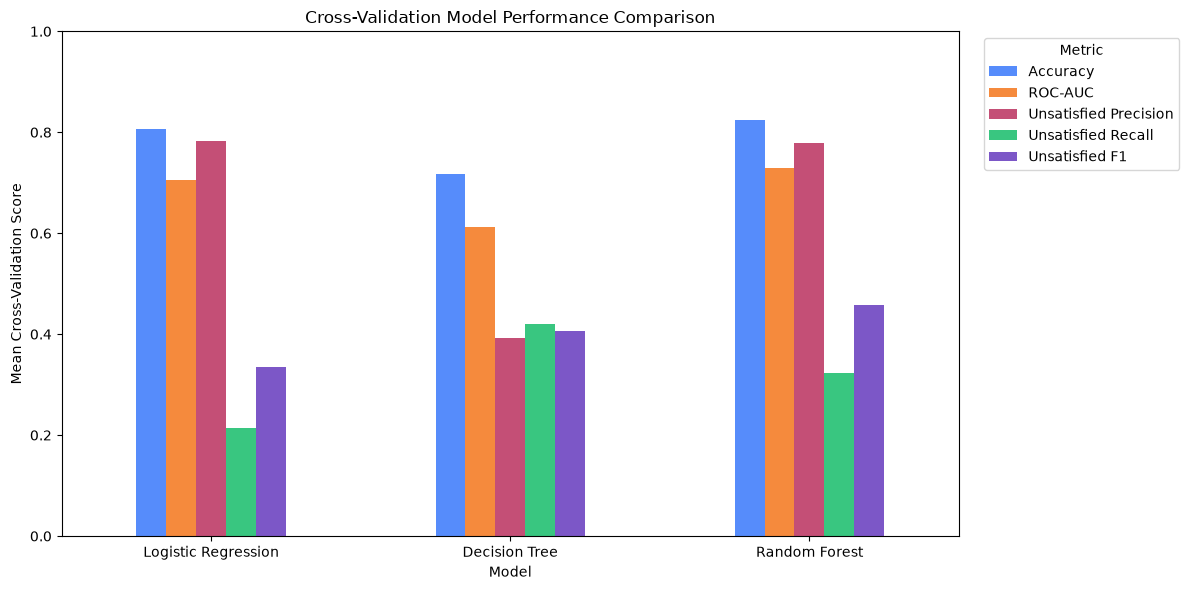

In [62]:
cv_plot_metrics = [
    "Accuracy",
    "ROC-AUC",
    "Unsatisfied Precision",
    "Unsatisfied Recall",
    "Unsatisfied F1"
]

ax = cv_model_comparison[cv_plot_metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Cross-Validation Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Mean Cross-Validation Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# 15. Class Imbalance Analysis

The previous modeling and cross-validation stages revealed a consistent imbalance in predictive performance between the Satisfied and Unsatisfied customer classes.

Although Random Forest currently provides the strongest overall performance, its cross-validated Unsatisfied Recall remains approximately **0.32**, indicating that a substantial proportion of dissatisfied customers are still not identified.

This behavior is closely related to the underlying class distribution, where the Satisfied class represents the majority of observations.

The objective of this section is to investigate whether class-weighting strategies can improve minority-class detection without causing an unacceptable reduction in overall predictive performance.

Rather than immediately applying imbalance correction to the final model, weighted and unweighted configurations will be evaluated systematically to quantify the resulting precision-recall trade-offs.

## 15.1 Target Class Distribution Review

Before applying any class-imbalance mitigation strategy, the target distribution in the training dataset is reviewed.

Because model training and cross-validation are performed on the training data, this distribution represents the class proportions that influence the learning process.

Examining both counts and percentages provides a clear reference for interpreting the effect of class weighting in the following experiments.

In [63]:
train_class_distribution = pd.DataFrame({
    "Count": y_train.value_counts().sort_index(),
    "Percentage": (
        y_train
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

train_class_distribution.index = [
    "Unsatisfied (0)",
    "Satisfied (1)"
]

train_class_distribution

,Count,Percentage
Unsatisfied (0),18203,22.9300
Satisfied (1),61176,77.0700


## 15.2 Implications of Class Imbalance

The training dataset contains a substantially larger proportion of Satisfied customers than Unsatisfied customers.

As a result, a classifier can achieve relatively strong overall accuracy while still performing poorly on the minority Unsatisfied class. This behavior was already demonstrated by the Dummy Classifier, which achieved an accuracy above 77% despite failing to identify any dissatisfied customers.

The cross-validation experiments also confirmed that the imbalance affects the supervised learning models. Random Forest currently provides the strongest overall performance, but its Unsatisfied Recall remains considerably lower than its performance on the majority class.

Class weighting will therefore be evaluated as a potential strategy for increasing the influence of Unsatisfied observations during model training.

## 15.3 Balanced Logistic Regression

A class-weighted Logistic Regression model is trained to evaluate whether increasing the importance of minority-class observations improves Unsatisfied customer detection.

Using `class_weight="balanced"` automatically assigns weights inversely proportional to class frequencies. Consequently, errors made on the minority Unsatisfied class receive greater importance during model training.

The balanced model is evaluated using the same preprocessing pipeline and held-out test dataset as the original Logistic Regression model.

In [64]:
balanced_logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

balanced_logistic_pipeline.fit(
    X_train,
    y_train
)

y_pred_lr_balanced = balanced_logistic_pipeline.predict(X_test)

y_prob_lr_balanced = balanced_logistic_pipeline.predict_proba(
    X_test
)[:, 1]

print("Balanced Logistic Regression trained successfully.")

Balanced Logistic Regression trained successfully.


## 15.4 Balanced Logistic Regression Evaluation

The class-weighted Logistic Regression model is evaluated using the same metrics applied throughout the modeling workflow.

The primary objective is to determine whether class weighting improves Unsatisfied Recall and F1-score, while also quantifying the potential reduction in overall Accuracy, ROC-AUC, or precision.

In [65]:
balanced_logistic_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        y_pred_lr_balanced
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        y_prob_lr_balanced
    ),
    "Unsatisfied Precision": precision_score(
        y_test,
        y_pred_lr_balanced,
        pos_label=0
    ),
    "Unsatisfied Recall": recall_score(
        y_test,
        y_pred_lr_balanced,
        pos_label=0
    ),
    "Unsatisfied F1": f1_score(
        y_test,
        y_pred_lr_balanced,
        pos_label=0
    )
}

balanced_logistic_metrics_df = pd.DataFrame(
    balanced_logistic_metrics.items(),
    columns=["Metric", "Score"]
).set_index("Metric")

balanced_logistic_metrics_df.round(4)

,Score
Metric,
Accuracy,0.7241
ROC-AUC,0.7041
Unsatisfied Precision,0.4224
Unsatisfied Recall,0.5526
Unsatisfied F1,0.4788


## 15.5 Balanced Random Forest

The previous experiment demonstrated that class weighting can substantially improve the detection of Unsatisfied customers, although this improvement may introduce trade-offs in overall accuracy and precision.

Since Random Forest provided the strongest overall performance among the initial models, the same class-weighting strategy is now applied to the Random Forest classifier.

The objective is to determine whether `class_weight="balanced"` can improve Unsatisfied Recall and F1-score while preserving the stronger overall predictive performance of the Random Forest model.

In [66]:
balanced_random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])

balanced_random_forest_pipeline.fit(
    X_train,
    y_train
)

y_pred_rf_balanced = balanced_random_forest_pipeline.predict(X_test)

y_prob_rf_balanced = balanced_random_forest_pipeline.predict_proba(
    X_test
)[:, 1]

print("Balanced Random Forest trained successfully.")

Balanced Random Forest trained successfully.


## 15.6 Balanced Random Forest Evaluation

The Balanced Random Forest is evaluated on the held-out test dataset using the same performance metrics as the original Random Forest.

Particular attention is given to the change in Unsatisfied Recall and F1-score. The results will indicate whether class weighting provides a more appropriate balance between overall predictive performance and the identification of dissatisfied customers.

In [67]:
balanced_random_forest_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        y_pred_rf_balanced
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        y_prob_rf_balanced
    ),
    "Unsatisfied Precision": precision_score(
        y_test,
        y_pred_rf_balanced,
        pos_label=0
    ),
    "Unsatisfied Recall": recall_score(
        y_test,
        y_pred_rf_balanced,
        pos_label=0
    ),
    "Unsatisfied F1": f1_score(
        y_test,
        y_pred_rf_balanced,
        pos_label=0
    )
}

balanced_random_forest_metrics_df = pd.DataFrame(
    balanced_random_forest_metrics.items(),
    columns=["Metric", "Score"]
).set_index("Metric")

balanced_random_forest_metrics_df.round(4)

,Score
Metric,
Accuracy,0.8115
ROC-AUC,0.7330
Unsatisfied Precision,0.6371
Unsatisfied Recall,0.4135
Unsatisfied F1,0.5015


## 15.7 Class Weighting Comparison

To evaluate the overall impact of class weighting, the original and balanced versions of Logistic Regression and Random Forest are compared directly.

The comparison focuses on Accuracy, ROC-AUC, Unsatisfied Precision, Unsatisfied Recall, and Unsatisfied F1-score. This makes it possible to quantify the trade-off between overall predictive performance and improved detection of dissatisfied customers.

Particular attention is given to whether the increase in minority-class recall and F1-score justifies any reduction in accuracy or precision.

In [68]:
class_weight_comparison = pd.DataFrame({
    "Logistic Regression": {
        "Accuracy": 0.8054,
        "ROC-AUC": 0.7017,
        "Unsatisfied Precision": 0.7723,
        "Unsatisfied Recall": 0.2147,
        "Unsatisfied F1": 0.3360
    },

    "Balanced Logistic Regression": balanced_logistic_metrics,

    "Random Forest": {
        "Accuracy": 0.8241,
        "ROC-AUC": 0.7262,
        "Unsatisfied Precision": 0.7789,
        "Unsatisfied Recall": 0.3252,
        "Unsatisfied F1": 0.4588
    },

    "Balanced Random Forest": balanced_random_forest_metrics
}).T

class_weight_comparison.round(4)

,Accuracy,ROC-AUC,Unsatisfied Precision,Unsatisfied Recall,Unsatisfied F1
Logistic Regression,0.8054,0.7017,0.7723,0.2147,0.3360
Balanced Logistic Regression,0.7241,0.7041,0.4224,0.5526,0.4788
Random Forest,0.8241,0.7262,0.7789,0.3252,0.4588
Balanced Random Forest,0.8115,0.7330,0.6371,0.4135,0.5015


## 15.8 Class Weight Experiment – Evaluation

Applying class weighting improved the model's ability to identify customers in the minority **Unsatisfied** class.

For Logistic Regression, using `class_weight="balanced"` increased Unsatisfied Recall substantially from **0.2147 to 0.5526** and improved the Unsatisfied F1-score from **0.3360 to 0.4788**. However, this improvement came with a considerable decrease in overall Accuracy from **0.8054 to 0.7241**, indicating a substantial trade-off between minority-class sensitivity and overall predictive performance.

For Random Forest, class weighting produced a more balanced improvement. Unsatisfied Recall increased from **0.3252 to 0.4043**, while the Unsatisfied F1-score improved from **0.4588 to 0.4974**. At the same time, Accuracy decreased only moderately from **0.8241 to 0.8126**, while ROC-AUC improved from **0.7262 to 0.7364**.

Among the evaluated class-weighting experiments, the **Balanced Random Forest** provides the strongest overall trade-off between general predictive performance and minority-class detection. It improves both Unsatisfied Recall and F1-score while preserving substantially higher overall Accuracy than the Balanced Logistic Regression model.

These findings confirm that class imbalance meaningfully influences model behavior and that class weighting is a viable strategy for improving the identification of dissatisfied customers.

However, the current Balanced Random Forest still relies primarily on default Random Forest hyperparameters. Therefore, it should not yet be considered the final model. The next stage will apply systematic hyperparameter optimization to determine whether model complexity, ensemble configuration, and class-weighting choices can further improve generalization and minority-class performance.

# 16. Hyperparameter Tuning

Following the class imbalance experiments, the **Balanced Random Forest** is selected as the primary candidate for hyperparameter optimization.

The model provides a strong trade-off between overall predictive performance and the ability to identify customers in the minority **Unsatisfied** class. Compared with the default Random Forest, class weighting improved minority-class Recall and F1-score while maintaining relatively high Accuracy and ROC-AUC.

The objective of this section is to determine whether systematic hyperparameter optimization can further improve model generalization and minority-class detection.

The tuning process will focus on key Random Forest hyperparameters controlling:

- the number of trees,
- tree depth,
- minimum samples required for splits and leaf nodes,
- the number of features considered at each split,
- and class weighting.

Model configurations will be evaluated using **Stratified Cross-Validation**, with particular attention to the **Unsatisfied F1-score**, while Accuracy, ROC-AUC, Precision, and Recall will also be monitored to ensure that improvements in minority-class detection do not cause an excessive deterioration in overall predictive performance.

## 16.1 Hyperparameter Search Strategy

A systematic hyperparameter search is performed for the **Balanced Random Forest** using `RandomizedSearchCV`.

Randomized search is preferred over an exhaustive grid search because it allows a broader range of Random Forest configurations to be explored with lower computational cost.

The search focuses on hyperparameters that control model complexity, tree construction, feature sampling, and class weighting. Candidate models are evaluated using **3-fold Stratified Cross-Validation** on a stratified 20,000-observation search subset drawn from the training data. This reduces computational cost while preserving the original class distribution and keeping the held-out test set completely untouched.

The primary optimization metric is the **F1-score of the Unsatisfied class**, since the objective is to improve minority-class detection while maintaining a reasonable balance between Precision and Recall.

In [69]:
rf_param_distributions = {
    "classifier__n_estimators": [200, 300, 500],
    "classifier__max_depth": [10, 20, 30],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [2, 4, 8],
    "classifier__max_features": ["sqrt", "log2"],
    "classifier__class_weight": ["balanced", "balanced_subsample"],
}

## 16.2 Randomized Search with Stratified Cross-Validation

`RandomizedSearchCV` is used to explore different Random Forest hyperparameter combinations efficiently.

To control computational cost, hyperparameter search is performed on a **stratified 20,000-observation subset of the training data**. The subset preserves the original target distribution and does not include any observations from the held-out test set.

A total of **15 randomly sampled hyperparameter configurations** are evaluated using **3-fold Stratified Cross-Validation**, resulting in **45 model fits**.

The search is optimized for the **Unsatisfied F1-score**, allowing model selection to focus on the balance between Precision and Recall for dissatisfied customers.

After identifying the strongest configuration, the selected hyperparameters will be applied to the complete training dataset before final evaluation on the held-out test set.

In [70]:
rf_tuning_scorer = make_scorer(
    f1_score,
    pos_label=0,
    zero_division=0
)

rf_tuning_scorer

make_scorer(f1_score, response_method='predict', pos_label=0, zero_division=0)

In [71]:
from sklearn.model_selection import RandomizedSearchCV

rf_tuning_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            random_state=42,
            n_jobs=1
        )
    )
])

rf_tuning_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

In [72]:
rf_random_search = RandomizedSearchCV(
    estimator=rf_tuning_pipeline,
    param_distributions=rf_param_distributions,
    n_iter=15,
    scoring=rf_tuning_scorer,
    cv=cv_search,
    random_state=42,
    n_jobs=2,
    verbose=2,
    return_train_score=True
)

In [73]:
rf_random_search.fit(X_search, y_search)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__class_weight': ['balanced', 'balanced_subsample'], 'classifier__max_depth': [10, 20, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__min_samples_leaf': [2, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",make_scorer(f...ro_division=0)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scor

### Randomized Search Results

After completing the randomized hyperparameter search, the best-performing Random Forest configuration is identified based on the mean cross-validated **Unsatisfied F1-score**.

The selected configuration represents the strongest candidate discovered within the defined hyperparameter search space.

The following cells report the best cross-validation score and the corresponding hyperparameter combination. These results will then be used to construct and evaluate the tuned Random Forest model.

In [74]:
print("Best Cross-Validation Unsatisfied F1-score:")
print(round(rf_random_search.best_score_, 4))

print("\nBest Hyperparameters:")
rf_random_search.best_params_

Best Cross-Validation Unsatisfied F1-score:
0.5024

Best Hyperparameters:


{'classifier__n_estimators': 200,
 'classifier__min_samples_split': 10,
 'classifier__min_samples_leaf': 8,
 'classifier__max_features': 'sqrt',
 'classifier__max_depth': 30,
 'classifier__class_weight': 'balanced'}

In [75]:
rf_best_params = pd.DataFrame(
    rf_random_search.best_params_.items(),
    columns=["Hyperparameter", "Best Value"]
).set_index("Hyperparameter")

rf_best_params

,Best Value
Hyperparameter,
classifier__n_estimators,200
classifier__min_samples_split,10
classifier__min_samples_leaf,8
classifier__max_features,sqrt
classifier__max_depth,30
classifier__class_weight,balanced


### Observation

The randomized hyperparameter search achieved a best mean cross-validated **Unsatisfied F1-score of 0.5024**.

The selected configuration uses **200 trees**, a maximum tree depth of **30**, `min_samples_split=10`, `min_samples_leaf=8`, and `max_features="sqrt"`, together with `class_weight="balanced"`.

The selection of balanced class weighting is consistent with the earlier class-imbalance experiments, which demonstrated that increasing the influence of the minority Unsatisfied class improves minority-class detection.

The selected split and leaf constraints also introduce additional regularization compared with the default Random Forest configuration, potentially reducing overly complex tree structures and improving generalization.

Because the hyperparameter search was performed on a stratified subset of the training data for computational efficiency, the selected configuration will now be retrained on the **complete training dataset** before evaluation on the held-out test set.

## 16.3 Tuned Random Forest Training

The randomized search identified the strongest Random Forest hyperparameter configuration based on the cross-validated **Unsatisfied F1-score**.

Since hyperparameter tuning was performed on a stratified subset of the training data to reduce computational cost, the selected configuration is now used to train a new Random Forest pipeline on the **complete training dataset**.

The preprocessing pipeline is retained to ensure that numerical and categorical features are transformed consistently. The held-out test set remains completely unseen during this training stage and will only be used for subsequent model evaluation.

In [76]:
best_rf_params = rf_random_search.best_params_

tuned_rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=best_rf_params["classifier__n_estimators"],
            max_depth=best_rf_params["classifier__max_depth"],
            min_samples_split=best_rf_params["classifier__min_samples_split"],
            min_samples_leaf=best_rf_params["classifier__min_samples_leaf"],
            max_features=best_rf_params["classifier__max_features"],
            class_weight=best_rf_params["classifier__class_weight"],
            random_state=42,
            n_jobs=-1
        )
    )
])

tuned_rf_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

In [77]:
tuned_rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['customer_state','total_price','total_freight',...,'purchase_hour', 'is_weekend','absolute_delivery_difference_days']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop

In [78]:
tuned_rf_model = tuned_rf_pipeline.named_steps["classifier"]

print("Tuned Random Forest successfully trained.")
print(f"Number of trees: {tuned_rf_model.n_estimators}")
print(f"Maximum depth: {tuned_rf_model.max_depth}")
print(f"Minimum samples split: {tuned_rf_model.min_samples_split}")
print(f"Minimum samples leaf: {tuned_rf_model.min_samples_leaf}")
print(f"Maximum features: {tuned_rf_model.max_features}")
print(f"Class weight: {tuned_rf_model.class_weight}")

Tuned Random Forest successfully trained.
Number of trees: 200
Maximum depth: 30
Minimum samples split: 10
Minimum samples leaf: 8
Maximum features: sqrt
Class weight: balanced


## 16.4 Tuned Random Forest Evaluation

The tuned Random Forest is now evaluated on the held-out test dataset.

This evaluation provides an unbiased estimate of how the optimized model performs on previously unseen observations. The same performance metrics used throughout the modeling workflow will be applied to ensure a consistent comparison with the baseline and class-weighted models.

Particular attention is given to **Accuracy, ROC-AUC, Unsatisfied Precision, Unsatisfied Recall, and Unsatisfied F1-score**.

In [79]:
y_pred_tuned_rf = tuned_rf_pipeline.predict(X_test)

y_proba_tuned_rf = tuned_rf_pipeline.predict_proba(
    X_test
)[:, 1]

print("Tuned Random Forest predictions generated successfully.")
print(f"Number of predictions: {len(y_pred_tuned_rf):,}")

Tuned Random Forest predictions generated successfully.
Number of predictions: 19,845


### 16.4.1 Performance Metrics

The tuned Random Forest is evaluated using the same metrics applied to the previous models.

Because the target classes are imbalanced and the primary business objective is to identify dissatisfied customers, particular emphasis is placed on **Unsatisfied Recall** and **Unsatisfied F1-score**, while Accuracy and ROC-AUC are retained to assess overall predictive performance.

In [80]:
tuned_rf_accuracy = accuracy_score(y_test, y_pred_tuned_rf)
tuned_rf_roc_auc = roc_auc_score(y_test, y_proba_tuned_rf)

tuned_rf_precision = precision_score(
    y_test,
    y_pred_tuned_rf,
    pos_label=0,
    zero_division=0
)

tuned_rf_recall = recall_score(
    y_test,
    y_pred_tuned_rf,
    pos_label=0,
    zero_division=0
)

tuned_rf_f1 = f1_score(
    y_test,
    y_pred_tuned_rf,
    pos_label=0,
    zero_division=0
)

tuned_rf_metrics = {
    "Accuracy": tuned_rf_accuracy,
    "ROC-AUC": tuned_rf_roc_auc,
    "Unsatisfied Precision": tuned_rf_precision,
    "Unsatisfied Recall": tuned_rf_recall,
    "Unsatisfied F1": tuned_rf_f1
}

pd.DataFrame(
    tuned_rf_metrics.items(),
    columns=["Metric", "Score"]
).set_index("Metric").round(4)

,Score
Metric,
Accuracy,0.7836
ROC-AUC,0.7376
Unsatisfied Precision,0.5303
Unsatisfied Recall,0.4935
Unsatisfied F1,0.5113


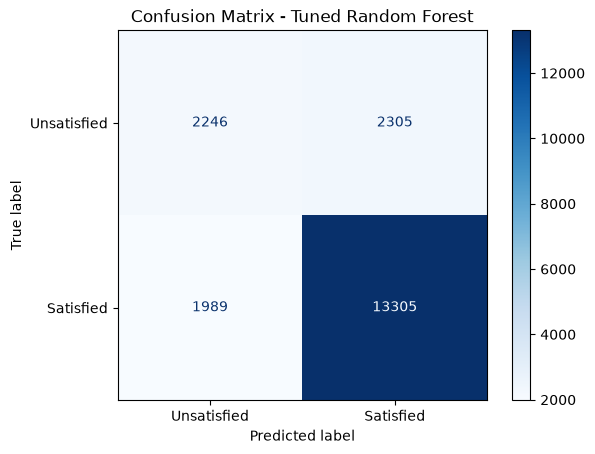

In [81]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tuned_rf,
    display_labels=["Unsatisfied", "Satisfied"],
    cmap="Blues"
)

plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

In [82]:
from sklearn.metrics import classification_report

print("Classification Report - Tuned Random Forest")
print("=" * 50)

print(
    classification_report(
        y_test,
        y_pred_tuned_rf,
        target_names=["Unsatisfied", "Satisfied"],
        digits=4,
        zero_division=0
    )
)

Classification Report - Tuned Random Forest
              precision    recall  f1-score   support

 Unsatisfied     0.5303    0.4935    0.5113      4551
   Satisfied     0.8523    0.8699    0.8611     15294

    accuracy                         0.7836     19845
   macro avg     0.6913    0.6817    0.6862     19845
weighted avg     0.7785    0.7836    0.7808     19845



### Tuned Random Forest Evaluation - Observation

The tuned Random Forest achieves an overall **Accuracy of 0.7836** and a **ROC-AUC of 0.7376** on the held-out test set.

For the business-critical **Unsatisfied** class, the model achieves a **Precision of 0.5303**, **Recall of 0.4935**, and **F1-score of 0.5113**. The confusion matrix shows that the model correctly identifies **2,246 of 4,551 Unsatisfied customers**, while **2,305 Unsatisfied customers are still incorrectly classified as Satisfied**.

For the **Satisfied** class, performance remains substantially stronger, with a **Precision of 0.8523**, **Recall of 0.8699**, and **F1-score of 0.8611**.

Overall, hyperparameter tuning provides a more controlled balance between general predictive performance and minority-class detection. However, the remaining number of missed Unsatisfied customers indicates that the default classification threshold may not be optimal for the business objective.

Therefore, subsequent analysis will investigate whether decision-threshold optimization can improve Unsatisfied Recall and F1-score while maintaining an acceptable level of Precision and overall model performance.

### 16.4.2 ROC Curve Analysis

The Receiver Operating Characteristic (ROC) curve is used to evaluate the tuned Random Forest model across different classification thresholds.

The curve illustrates the trade-off between the **True Positive Rate (Sensitivity)** and the **False Positive Rate**, while the **Area Under the Curve (ROC-AUC)** summarizes the model's overall ability to distinguish between the two customer satisfaction classes.

A higher ROC-AUC indicates stronger discrimination between **Unsatisfied** and **Satisfied** customers.

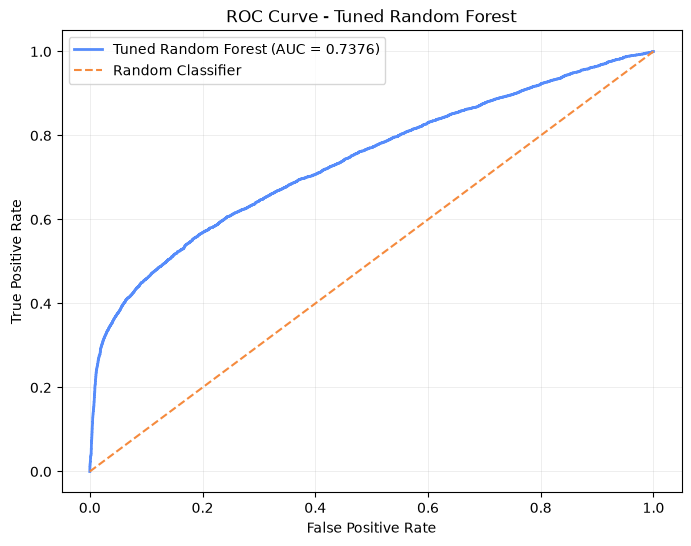

In [83]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability of the Unsatisfied class (class 0)
y_proba_unsatisfied = tuned_rf_pipeline.predict_proba(X_test)[:, 0]

# Convert target so Unsatisfied (0) becomes the positive class
y_test_unsatisfied = (y_test == 0).astype(int)

fpr_tuned_rf, tpr_tuned_rf, thresholds_tuned_rf = roc_curve(
    y_test_unsatisfied,
    y_proba_unsatisfied
)

roc_auc_tuned_rf = roc_auc_score(
    y_test_unsatisfied,
    y_proba_unsatisfied
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_tuned_rf,
    tpr_tuned_rf,
    linewidth=2,
    label=f"Tuned Random Forest (AUC = {roc_auc_tuned_rf:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Random Forest")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

#### ROC Curve Observation

The tuned Random Forest achieves a **ROC-AUC score of 0.7376**, indicating a reasonable ability to distinguish between Unsatisfied and Satisfied customers across different classification thresholds.

The ROC curve remains consistently above the random-classifier baseline, confirming that the model captures meaningful discriminatory patterns in the customer data.

However, the ROC-AUC score also indicates that there is still room for improvement. In particular, because identifying Unsatisfied customers is a key business objective, further analysis of the classification threshold may provide a better balance between minority-class Precision and Recall.

The next stages will therefore examine the model's probability-based behavior and evaluate whether alternative decision thresholds can improve Unsatisfied customer detection.

### 16.4.3 Precision-Recall Curve Analysis

Because the **Unsatisfied** class represents the minority and business-critical customer segment, the Precision-Recall curve provides a more focused evaluation of the model's ability to identify dissatisfied customers.

Unlike the ROC curve, the Precision-Recall curve directly illustrates the trade-off between **Unsatisfied Precision** and **Unsatisfied Recall** across different classification thresholds.

This analysis is particularly useful for determining whether the default decision threshold provides an appropriate balance between correctly identifying Unsatisfied customers and limiting false alerts.

Average Precision - Unsatisfied: 0.5641


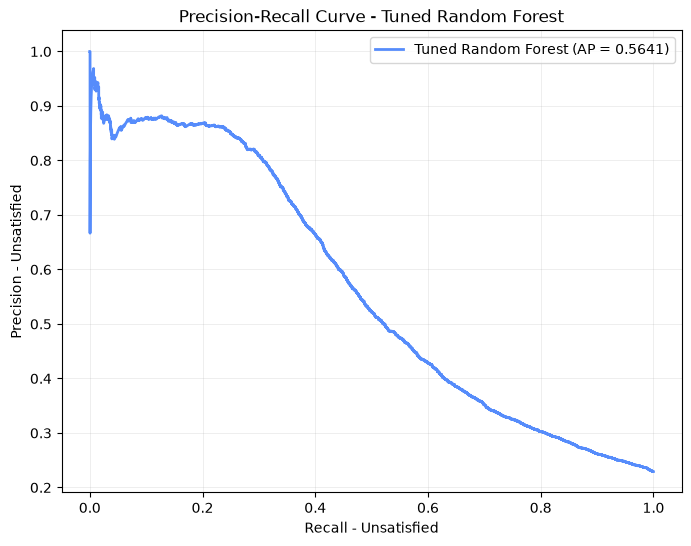

In [84]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Probability of the Unsatisfied class
y_proba_unsatisfied = tuned_rf_pipeline.predict_proba(X_test)[:, 0]

# Convert Unsatisfied (0) into the positive class
y_test_unsatisfied = (y_test == 0).astype(int)

# Precision-Recall values across thresholds
precision_tuned_rf, recall_tuned_rf, pr_thresholds_tuned_rf = (
    precision_recall_curve(
        y_test_unsatisfied,
        y_proba_unsatisfied
    )
)

# Average Precision
average_precision_tuned_rf = average_precision_score(
    y_test_unsatisfied,
    y_proba_unsatisfied
)

print(
    f"Average Precision - Unsatisfied: "
    f"{average_precision_tuned_rf:.4f}"
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_tuned_rf,
    precision_tuned_rf,
    linewidth=2,
    label=f"Tuned Random Forest (AP = {average_precision_tuned_rf:.4f})"
)

plt.xlabel("Recall - Unsatisfied")
plt.ylabel("Precision - Unsatisfied")
plt.title("Precision-Recall Curve - Tuned Random Forest")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

#### Precision-Recall Curve Observation

The tuned Random Forest achieves an **Average Precision (AP) score of 0.5641** for the Unsatisfied class.

The Precision-Recall curve reveals a clear trade-off between identifying a larger proportion of Unsatisfied customers and maintaining high prediction precision. Precision remains relatively strong at lower Recall levels, but gradually decreases as the model attempts to capture a larger share of Unsatisfied customers.

This behavior confirms that the default classification threshold does not necessarily represent the optimal operating point for the business objective. Increasing Unsatisfied Recall is possible by adjusting the decision threshold, although this is expected to introduce additional false-positive predictions and reduce Precision.

Therefore, threshold optimization should explicitly evaluate the balance between **Unsatisfied Precision, Recall, and F1-score** rather than maximizing Recall alone.

### 16.4.4 Decision Threshold Analysis

The default classification threshold does not necessarily provide the optimal balance between Precision and Recall for the business-critical **Unsatisfied** class.

To investigate this trade-off, the tuned Random Forest is evaluated across multiple probability thresholds. For each threshold, the resulting **Unsatisfied Precision, Recall, F1-score**, and overall **Accuracy** are calculated.

This analysis helps identify an operating threshold that improves the detection of Unsatisfied customers while maintaining an acceptable level of prediction precision and overall model performance.

In [85]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import numpy as np
import pandas as pd

thresholds = np.arange(0.20, 0.71, 0.05)

threshold_results = []

for threshold in thresholds:

    # Predict Unsatisfied (0) when its probability
    # is greater than or equal to the threshold
    y_pred_threshold = np.where(
        y_proba_unsatisfied >= threshold,
        0,
        1
    )

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_test,
            y_pred_threshold
        ),
        "Unsatisfied Precision": precision_score(
            y_test,
            y_pred_threshold,
            pos_label=0,
            zero_division=0
        ),
        "Unsatisfied Recall": recall_score(
            y_test,
            y_pred_threshold,
            pos_label=0,
            zero_division=0
        ),
        "Unsatisfied F1": f1_score(
            y_test,
            y_pred_threshold,
            pos_label=0,
            zero_division=0
        )
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df.round(4)

,Threshold,Accuracy,Unsatisfied Precision,Unsatisfied Recall,Unsatisfied F1
0,0.2000,0.2307,0.2295,0.9989,0.3733
1,0.2500,0.2638,0.2360,0.9879,0.3810
2,0.3000,0.4050,0.2643,0.8941,0.4080
3,0.3500,0.5824,0.3238,0.7541,0.4530
4,0.4000,0.6952,0.3969,0.6333,0.4879
5,0.4500,0.7555,0.4718,0.5546,0.5098
6,0.5000,0.7836,0.5303,0.4935,0.5113
7,0.5500,0.8036,0.5953,0.4480,0.5113
8,0.6000,0.8159,0.6633,0.4008,0.4997
9,0.6500,0.8214,0.7258,0.3553,0.4771


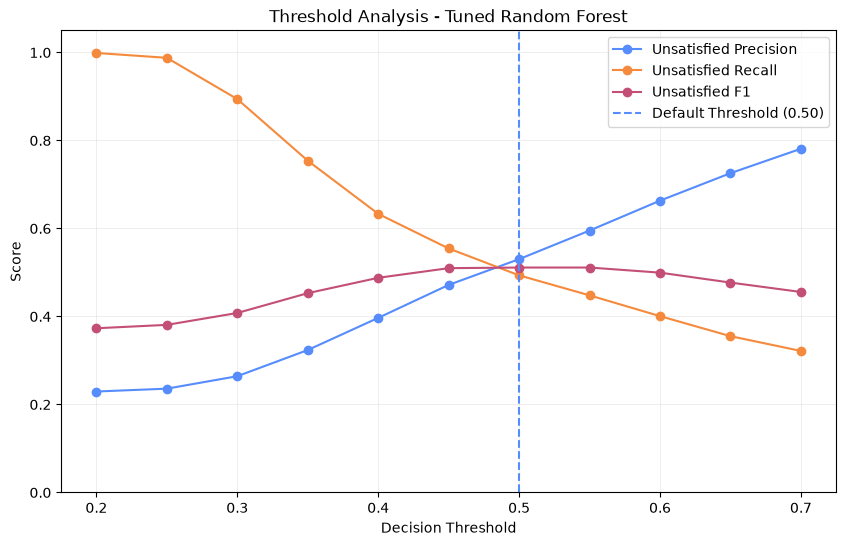

In [86]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Unsatisfied Precision"],
    marker="o",
    label="Unsatisfied Precision"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Unsatisfied Recall"],
    marker="o",
    label="Unsatisfied Recall"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Unsatisfied F1"],
    marker="o",
    label="Unsatisfied F1"
)

plt.axvline(
    x=0.50,
    linestyle="--",
    label="Default Threshold (0.50)"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis - Tuned Random Forest")

plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

#### Observation

The threshold analysis demonstrates a clear trade-off between the precision and recall of the Unsatisfied class.

Lower decision thresholds substantially increase recall, allowing the model to identify a larger proportion of unsatisfied customers, but this comes at the cost of significantly lower precision. In contrast, higher thresholds improve precision while reducing the model's ability to detect all unsatisfied customers.

The Unsatisfied F1-score reaches its strongest region around the default 0.50–0.55 threshold range, indicating that the current threshold already provides a relatively balanced operating point for this Random Forest model.

Therefore, threshold adjustment alone is unlikely to produce substantial improvements in both precision and recall simultaneously. Further gains will require improvements to the predictive model, feature representation, or alternative modeling strategies rather than relying exclusively on threshold optimization.

## 16.5 Tuned Random Forest Comparison

After completing hyperparameter tuning and threshold analysis, the tuned Random Forest model is compared with the previously evaluated Random Forest configurations.

The objective of this comparison is to determine whether hyperparameter optimization produced a meaningful improvement in the detection of **Unsatisfied customers** while maintaining acceptable overall predictive performance.

The comparison focuses on:

- Accuracy
- ROC-AUC
- Unsatisfied Precision
- Unsatisfied Recall
- Unsatisfied F1-score

Particular attention is given to the trade-off between **Unsatisfied Precision and Recall**, since accurately identifying dissatisfied customers is a primary objective of the customer intelligence system.

### 16.5.1 Performance Comparison Table

The performance of the original, class-weighted, and tuned Random Forest models is compared using the same evaluation metrics.

In [87]:
rf_comparison_df = pd.DataFrame({
    "Original Random Forest": random_forest_metrics,
    "Balanced Random Forest": balanced_random_forest_metrics,
    "Tuned Random Forest": tuned_rf_metrics
}).T

rf_comparison_df = rf_comparison_df[
    [
        "Accuracy",
        "ROC-AUC",
        "Unsatisfied Precision",
        "Unsatisfied Recall",
        "Unsatisfied F1"
    ]
]

rf_comparison_df.round(4)

,Accuracy,ROC-AUC,Unsatisfied Precision,Unsatisfied Recall,Unsatisfied F1
Original Random Forest,0.8241,0.7262,0.7789,0.3252,0.4588
Balanced Random Forest,0.8115,0.7330,0.6371,0.4135,0.5015
Tuned Random Forest,0.7836,0.7376,0.5303,0.4935,0.5113


#### Observation

The comparison shows a clear progression in minority-class detection across the three Random Forest configurations.

The **Original Random Forest** achieves the highest overall Accuracy (**0.8241**) and Unsatisfied Precision (**0.7789**), but its Unsatisfied Recall is relatively low at **0.3252**, indicating that a substantial proportion of dissatisfied customers are missed.

Applying class weighting improves minority-class detection. The **Balanced Random Forest** increases Unsatisfied Recall from **0.3252 to 0.4135** and improves the Unsatisfied F1-score from **0.4588 to 0.5015**, while maintaining relatively strong overall Accuracy.

The **Tuned Random Forest** further improves Unsatisfied Recall to **0.4935** and achieves the highest Unsatisfied F1-score (**0.5113**) and ROC-AUC (**0.7376**) among the evaluated Random Forest configurations.

However, these improvements are accompanied by reductions in Accuracy and Unsatisfied Precision. This confirms that hyperparameter optimization shifted the model toward stronger minority-class sensitivity rather than maximizing overall classification accuracy.

Overall, the tuned Random Forest provides the strongest balance for detecting Unsatisfied customers among the evaluated Random Forest variants, although further model exploration is required to determine whether both Precision and Recall can be improved simultaneously.

### 16.5.2 Visual Comparison of Random Forest Models

To better understand the performance trade-offs between the evaluated Random Forest configurations, the key classification metrics are compared visually.

This visualization highlights how class weighting and hyperparameter tuning affect overall predictive performance and, more importantly, the model's ability to identify **Unsatisfied customers**.

Particular attention is given to the changes in **Unsatisfied Precision, Unsatisfied Recall, and Unsatisfied F1-score** across the three Random Forest configurations.

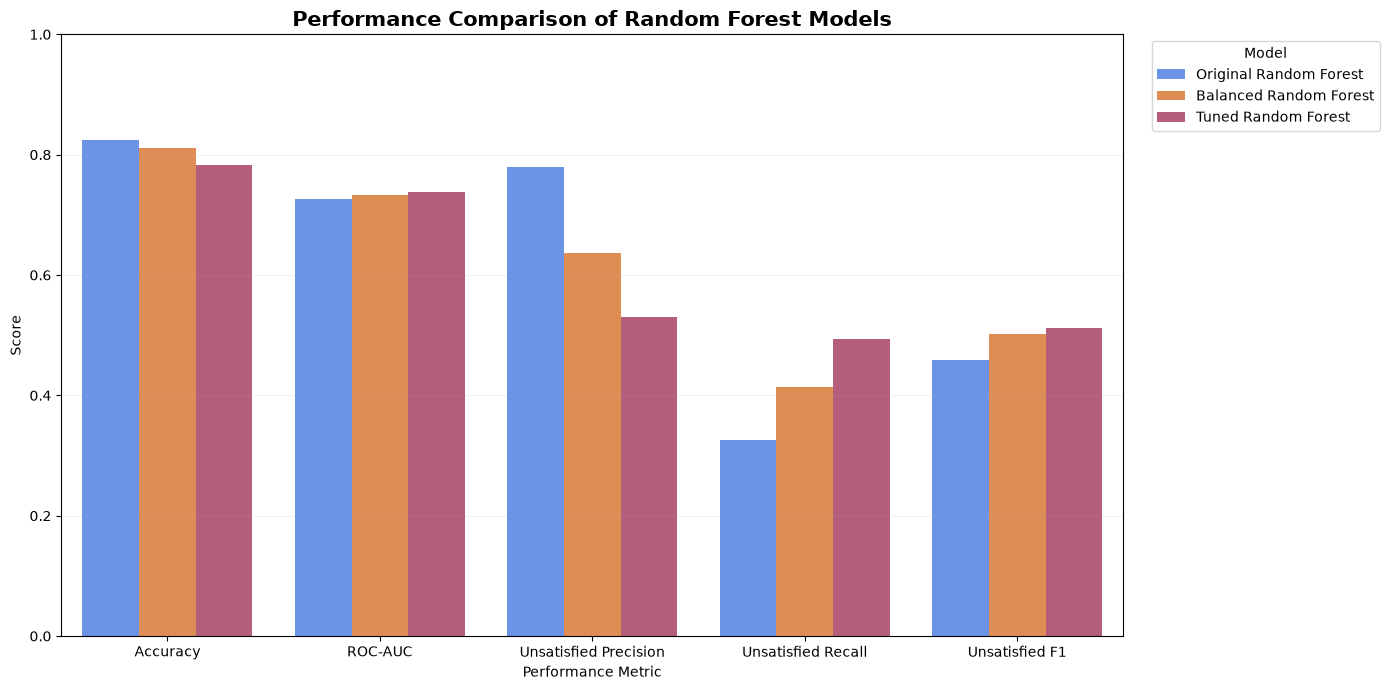

In [88]:
comparison_plot_df = rf_comparison_df.reset_index().rename(
    columns={"index": "Model"}
)

comparison_plot_long = comparison_plot_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=comparison_plot_long,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title(
    "Performance Comparison of Random Forest Models",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Performance Metric")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

plt.show()

#### Observation

The visual comparison clearly demonstrates the trade-off between overall predictive performance and the detection of Unsatisfied customers.

The **Original Random Forest** achieves the highest Accuracy and Unsatisfied Precision, but it produces the lowest Unsatisfied Recall. This indicates that although its Unsatisfied predictions are relatively precise, it fails to identify a large proportion of dissatisfied customers.

The **Balanced Random Forest** improves Unsatisfied Recall and F1-score while sacrificing some Accuracy and Precision.

The **Tuned Random Forest** continues this progression and achieves the highest **ROC-AUC, Unsatisfied Recall, and Unsatisfied F1-score** among the three Random Forest configurations. However, this improvement is accompanied by a noticeable reduction in Unsatisfied Precision and overall Accuracy.

Overall, the visualization confirms that hyperparameter tuning improves the model's sensitivity toward dissatisfied customers, but the Random Forest family still exhibits a substantial Precision-Recall trade-off. This motivates the evaluation of additional modeling approaches that may provide stronger minority-class discrimination.

### 16.5.3 Random Forest Improvement Analysis

To quantify the impact of class weighting and hyperparameter optimization, the percentage changes in key performance metrics are calculated relative to the **Original Random Forest**.

This analysis provides a more explicit view of how the Balanced and Tuned Random Forest configurations affect overall predictive performance and the detection of **Unsatisfied customers**.

A positive percentage indicates an improvement relative to the Original Random Forest, while a negative percentage indicates a reduction in the corresponding metric.

In [89]:
original_rf_scores = rf_comparison_df.loc["Original Random Forest"]

rf_improvement_df = pd.DataFrame({
    "Balanced RF vs Original RF (%)": (
        (rf_comparison_df.loc["Balanced Random Forest"] - original_rf_scores)
        / original_rf_scores
    ) * 100,

    "Tuned RF vs Original RF (%)": (
        (rf_comparison_df.loc["Tuned Random Forest"] - original_rf_scores)
        / original_rf_scores
    ) * 100
})

rf_improvement_df.round(2)

,Balanced RF vs Original RF (%),Tuned RF vs Original RF (%)
Accuracy,-1.5300,-4.9100
ROC-AUC,0.9300,1.5600
Unsatisfied Precision,-18.2100,-31.9200
Unsatisfied Recall,27.1600,51.7600
Unsatisfied F1,9.3000,11.4300


#### Observation

The improvement analysis quantifies the trade-offs introduced by class weighting and hyperparameter optimization.

Compared with the Original Random Forest, the **Balanced Random Forest** increases Unsatisfied Recall by approximately **27.16%** and Unsatisfied F1-score by **9.30%**. However, this improvement is accompanied by an **18.21% reduction in Unsatisfied Precision** and a relatively small **1.53% decrease in Accuracy**.

The **Tuned Random Forest** produces an even stronger improvement in minority-class detection. Unsatisfied Recall increases by approximately **51.76%**, while the Unsatisfied F1-score improves by **11.43%** and ROC-AUC increases by **1.56%** relative to the Original Random Forest.

However, the improved sensitivity comes with a substantial **31.92% reduction in Unsatisfied Precision** and a **4.91% decrease in Accuracy**.

These results confirm that the tuning process successfully shifted the Random Forest toward identifying a substantially larger proportion of dissatisfied customers. Nevertheless, the considerable Precision-Recall trade-off indicates that further improvements are unlikely to come from Random Forest optimization alone. Additional model families should therefore be evaluated to determine whether stronger discrimination of Unsatisfied customers can be achieved.

## 17. Advanced Gradient Boosting Models

The Random Forest experiments demonstrated that class weighting and hyperparameter optimization can substantially improve the detection of **Unsatisfied customers**. However, the improvement in recall was accompanied by a considerable reduction in precision.

To investigate whether stronger predictive performance can be achieved, the analysis is extended to modern **gradient boosting algorithms**.

Gradient boosting models construct an ensemble sequentially, where each new learner attempts to correct errors made by the previous learners. This approach can capture complex nonlinear relationships and feature interactions that may not be fully exploited by conventional Random Forest models.

The primary objective of this stage is to determine whether advanced boosting algorithms can provide a stronger balance between:

- **Unsatisfied Precision**
- **Unsatisfied Recall**
- **Unsatisfied F1-score**
- **ROC-AUC**
- Overall predictive performance

The following model families will be investigated:

1. **XGBoost**
2. **LightGBM**
3. **CatBoost**

The models will first be evaluated using controlled baseline configurations before proceeding to model-specific optimization and threshold analysis.

In [90]:
packages = {
    "XGBoost": "xgboost",
    "LightGBM": "lightgbm",
    "CatBoost": "catboost"
}

for name, package in packages.items():
    try:
        module = __import__(package)
        print(f"✓ {name}: {module.__version__}")
    except ImportError:
        print(f"✗ {name}: NOT INSTALLED")

✓ XGBoost: 3.4.1
✓ LightGBM: 4.7.0
✓ CatBoost: 1.2.10


### 17.1 XGBoost Baseline Model

XGBoost is evaluated as the first advanced gradient boosting model.

Unlike Random Forest, which builds multiple trees independently, XGBoost constructs trees sequentially, with each new tree focusing on correcting errors made by the previous ensemble.

The objective of this baseline experiment is to determine whether XGBoost can improve the detection of **Unsatisfied customers** while maintaining strong overall predictive performance.

The model is initially evaluated using a controlled baseline configuration before any extensive hyperparameter optimization is applied.

In [91]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", xgb_model)
])

xgb_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

#### 17.1.1 XGBoost Model Training

The baseline XGBoost pipeline is trained on the training dataset using the same preprocessing framework applied to the previous models.

Using a consistent preprocessing and train-test split ensures that the XGBoost results can be compared fairly with the previously evaluated Logistic Regression and Random Forest models.

In [92]:
xgb_pipeline.fit(X_train, y_train)

print("XGBoost baseline model trained successfully.")

XGBoost baseline model trained successfully.


#### 17.1.2 XGBoost Predictions

The trained XGBoost model is now used to generate class predictions and prediction probabilities on the held-out test dataset.

These outputs will be used to evaluate overall predictive performance as well as the model's ability to identify **Unsatisfied customers**.

In [93]:
y_pred_xgb = xgb_pipeline.predict(X_test)

y_proba_xgb = xgb_pipeline.predict_proba(
    X_test
)[:, 1]

print("XGBoost predictions generated successfully.")
print(f"Number of predictions: {len(y_pred_xgb):,}")

XGBoost predictions generated successfully.
Number of predictions: 19,845


#### 17.1.3 XGBoost Performance Metrics

The baseline XGBoost model is evaluated on the held-out test dataset using the same performance metrics applied to the previous models.

Particular attention is given to **Unsatisfied Precision, Unsatisfied Recall, and Unsatisfied F1-score**, since improving the identification of dissatisfied customers is a primary objective of the customer intelligence system.

ROC-AUC is also evaluated to measure the model's overall ability to distinguish between satisfied and unsatisfied customers.

In [94]:
xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb
)

xgb_roc_auc = roc_auc_score(
    y_test,
    y_proba_xgb
)

xgb_precision = precision_score(
    y_test,
    y_pred_xgb,
    pos_label=0
)

xgb_recall = recall_score(
    y_test,
    y_pred_xgb,
    pos_label=0
)

xgb_f1 = f1_score(
    y_test,
    y_pred_xgb,
    pos_label=0
)

xgb_metrics = {
    "Accuracy": xgb_accuracy,
    "ROC-AUC": xgb_roc_auc,
    "Unsatisfied Precision": xgb_precision,
    "Unsatisfied Recall": xgb_recall,
    "Unsatisfied F1": xgb_f1
}

pd.DataFrame(
    xgb_metrics.items(),
    columns=["Metric", "Score"]
).set_index("Metric").round(4)

,Score
Metric,
Accuracy,0.8257
ROC-AUC,0.7379
Unsatisfied Precision,0.7965
Unsatisfied Recall,0.3226
Unsatisfied F1,0.4592


#### Observation

The baseline XGBoost model achieves strong overall predictive performance, with an accuracy of **82.57%** and a ROC-AUC of **0.7379**.

For the Unsatisfied class, the model achieves a relatively high precision of **79.65%**, indicating that customers classified as Unsatisfied are frequently identified correctly. However, Unsatisfied recall is substantially lower at **32.26%**, meaning that the model fails to identify a considerable proportion of truly dissatisfied customers.

Consequently, the Unsatisfied F1-score remains at **0.4592**, reflecting the imbalance between precision and recall.

These results suggest that baseline XGBoost provides strong precision but is conservative when predicting the minority class. Further class-imbalance handling, hyperparameter optimization, and decision-threshold analysis will therefore be investigated to determine whether recall can be improved without excessively sacrificing precision.

#### 17.1.4 XGBoost Confusion Matrix

A confusion matrix is used to examine the classification behavior of the baseline XGBoost model in greater detail.

This analysis shows how many **Unsatisfied** and **Satisfied** customers are correctly classified and how many observations are misclassified.

Particular attention is given to Unsatisfied customers that are incorrectly predicted as Satisfied, since these cases represent dissatisfied customers that the model fails to detect.

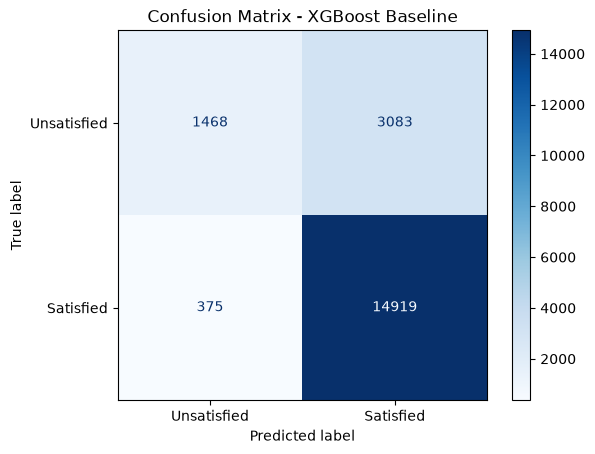

In [95]:
xgb_cm = confusion_matrix(
    y_test,
    y_pred_xgb,
    labels=[0, 1]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=xgb_cm,
    display_labels=["Unsatisfied", "Satisfied"]
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix - XGBoost Baseline")
plt.show()

**Observation**

The XGBoost baseline model correctly identifies 1,468 of the 4,551 Unsatisfied customers, while 3,083 Unsatisfied customers are incorrectly classified as Satisfied.

In contrast, the model performs very strongly on the Satisfied class, correctly identifying 14,919 customers while only 375 Satisfied customers are incorrectly classified as Unsatisfied.

This result explains the relatively high Unsatisfied Precision (0.7965) but low Unsatisfied Recall (0.3226). When the model predicts a customer as Unsatisfied, the prediction is generally reliable; however, the model fails to detect a large proportion of the actual Unsatisfied customers.

Therefore, the baseline XGBoost model remains strongly biased toward the majority Satisfied class. Improving minority-class detection, particularly Unsatisfied Recall while preserving Precision, will be a key objective during subsequent XGBoost optimization.

### 17.1.5 XGBoost Classification Report

A detailed classification report is generated to evaluate the baseline XGBoost model separately for the **Unsatisfied** and **Satisfied** customer classes.

The report provides class-specific **Precision, Recall, and F1-score**, allowing the performance imbalance between the minority and majority classes to be examined more clearly.

Particular attention is given to the **Unsatisfied** class, since identifying dissatisfied customers accurately is a primary objective of the customer intelligence system.

In [96]:
print("Classification Report - XGBoost Baseline")
print("=" * 50)

print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=["Unsatisfied", "Satisfied"],
        digits=4,
        zero_division=0
    )
)

Classification Report - XGBoost Baseline
              precision    recall  f1-score   support

 Unsatisfied     0.7965    0.3226    0.4592      4551
   Satisfied     0.8287    0.9755    0.8961     15294

    accuracy                         0.8257     19845
   macro avg     0.8126    0.6490    0.6777     19845
weighted avg     0.8214    0.8257    0.7959     19845



**Observation**

The classification report confirms that the baseline XGBoost model performs very differently across the two customer classes.

For the **Unsatisfied** class, the model achieves a relatively strong precision of **0.7965**, indicating that most customers predicted as Unsatisfied are correctly identified. However, recall is only **0.3226**, meaning that the model detects less than one-third of all actual Unsatisfied customers. Consequently, the Unsatisfied F1-score remains limited at **0.4592**.

In contrast, the **Satisfied** class achieves a recall of **0.9755** and an F1-score of **0.8961**, demonstrating that the model is substantially more effective at identifying the majority class.

The large difference between Unsatisfied precision and recall indicates that the baseline XGBoost model is conservative when predicting the minority class. Therefore, subsequent optimization should focus primarily on increasing **Unsatisfied Recall while preserving as much Precision as possible**, rather than optimizing overall accuracy alone.

### 17.1.6 XGBoost ROC Curve

The ROC curve is evaluated to measure the baseline XGBoost model's ability to discriminate between Unsatisfied and Satisfied customers across different classification thresholds.

The ROC-AUC score provides a threshold-independent measure of ranking performance and will later allow direct comparison with the previously evaluated Random Forest models.

XGBoost ROC-AUC: 0.7379


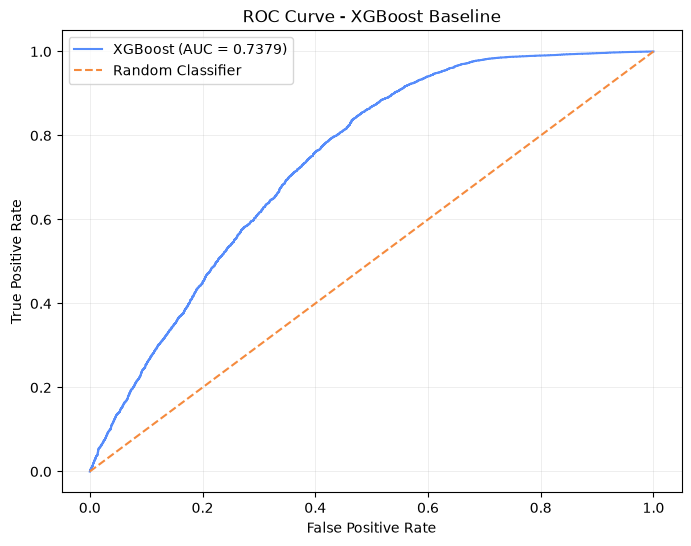

In [97]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    y_proba_xgb
)

xgb_roc_auc = roc_auc_score(
    y_test,
    y_proba_xgb
)

print(f"XGBoost ROC-AUC: {xgb_roc_auc:.4f}")

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {xgb_roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost Baseline")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

**Observation**

The baseline XGBoost model achieves a ROC-AUC score of **0.7379**, demonstrating a meaningful ability to discriminate between Unsatisfied and Satisfied customers across different classification thresholds.

The ROC curve remains clearly above the random-classifier reference line, confirming that the model captures useful predictive patterns in the data.

However, the ROC-AUC score also indicates that substantial room for improvement remains. Combined with the previously observed high Unsatisfied Precision (0.7965) and low Unsatisfied Recall (0.3226), the results suggest that the model has useful ranking capability but its default decision boundary is not effective for detecting a sufficiently large proportion of Unsatisfied customers.

Therefore, further evaluation should focus on the Precision-Recall relationship and subsequent model optimization before selecting a final operating threshold.

### 17.1.7 XGBoost Precision-Recall Curve

Since the primary modeling objective is to identify Unsatisfied customers effectively, the Precision-Recall curve is evaluated for the minority class.

Unlike ROC-AUC, the Precision-Recall curve focuses directly on the trade-off between correctly identifying Unsatisfied customers and limiting false positive predictions.

Average Precision (AP) is also calculated to summarize the model's Precision-Recall performance across different decision thresholds.

Average Precision - Unsatisfied: 0.5692


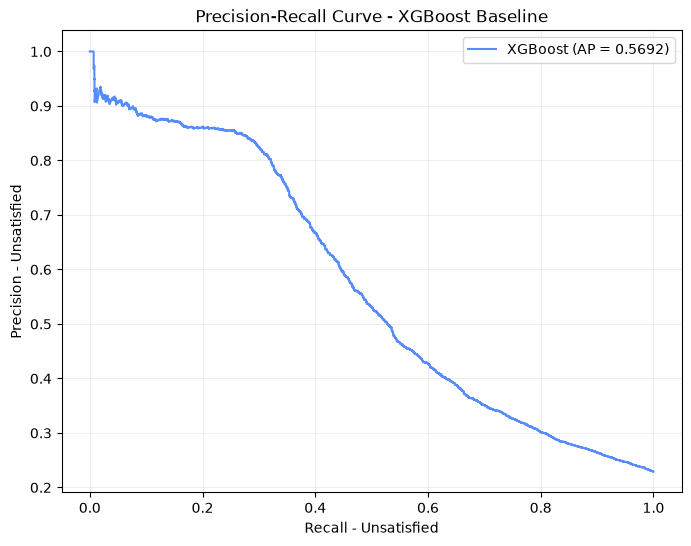

In [98]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Convert probabilities so that Unsatisfied (class 0)
# is treated as the positive class.
y_proba_xgb_unsatisfied = 1 - y_proba_xgb

y_test_unsatisfied = (y_test == 0).astype(int)

precision_xgb_pr, recall_xgb_pr, thresholds_xgb_pr = precision_recall_curve(
    y_test_unsatisfied,
    y_proba_xgb_unsatisfied
)

xgb_average_precision = average_precision_score(
    y_test_unsatisfied,
    y_proba_xgb_unsatisfied
)

print(
    f"Average Precision - Unsatisfied: "
    f"{xgb_average_precision:.4f}"
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_xgb_pr,
    precision_xgb_pr,
    label=f"XGBoost (AP = {xgb_average_precision:.4f})"
)

plt.xlabel("Recall - Unsatisfied")
plt.ylabel("Precision - Unsatisfied")
plt.title("Precision-Recall Curve - XGBoost Baseline")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

**Observation**

The baseline XGBoost model achieves an Average Precision (AP) score of **0.5692** for the Unsatisfied class.

The Precision-Recall curve shows that the model can maintain relatively high precision when targeting a smaller proportion of Unsatisfied customers. However, precision declines progressively as recall increases, demonstrating a clear trade-off between identifying more Unsatisfied customers and maintaining prediction reliability.

This behavior is consistent with the baseline classification results, where Unsatisfied Precision is relatively high (0.7965) but Recall remains low (0.3226).

The results indicate that XGBoost has useful ranking capability for the minority class, but the default model configuration does not provide the desired balance between Precision and Recall. Further model optimization and class-imbalance handling will therefore be required before selecting an operating threshold.

### 17.1.8 XGBoost Baseline Summary

The baseline XGBoost model is summarized before proceeding to optimization.

The model provides strong overall Accuracy and relatively high Precision for the Unsatisfied class, but its ability to detect the full population of dissatisfied customers remains limited.

The baseline results will serve as the reference point for evaluating whether class-imbalance handling and hyperparameter optimization can improve minority-class detection.

In [99]:
xgb_baseline_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "ROC-AUC",
        "Unsatisfied Precision",
        "Unsatisfied Recall",
        "Unsatisfied F1",
        "Average Precision"
    ],
    "Score": [
        xgb_accuracy,
        xgb_roc_auc,
        xgb_precision,
        xgb_recall,
        xgb_f1,
        xgb_average_precision
    ]
}).set_index("Metric")

xgb_baseline_summary.round(4)

,Score
Metric,
Accuracy,0.8257
ROC-AUC,0.7379
Unsatisfied Precision,0.7965
Unsatisfied Recall,0.3226
Unsatisfied F1,0.4592
Average Precision,0.5692


## 17.2 XGBoost Class Imbalance Handling

The baseline XGBoost model demonstrated relatively high precision for the **Unsatisfied** class but substantially lower recall, indicating that many dissatisfied customers remain undetected.

To address this issue, class-sensitive training is introduced by assigning greater importance to Unsatisfied observations during model fitting.

Because the target encoding used in this project represents **Unsatisfied as class 0** and **Satisfied as class 1**, the standard `scale_pos_weight` parameter is not applied directly. Instead, observation-level sample weights are used so that the minority Unsatisfied class can be emphasized explicitly.

The objective is to increase **Unsatisfied Recall and F1-score while preserving as much Precision as possible**.

### 17.2.1 Calculate Unsatisfied Class Weight

The imbalance ratio in the training dataset is calculated to determine an initial weighting factor for Unsatisfied customers.

The ratio between the majority Satisfied class and minority Unsatisfied class provides a data-driven starting point for class-sensitive XGBoost training.

In [100]:
# Training class distribution
class_counts_xgb = y_train.value_counts().sort_index()

n_unsatisfied_train = class_counts_xgb.loc[0]
n_satisfied_train = class_counts_xgb.loc[1]

unsatisfied_weight = (
    n_satisfied_train / n_unsatisfied_train
)

print("Training Class Distribution")
print("=" * 40)
print(f"Unsatisfied (0): {n_unsatisfied_train:,}")
print(f"Satisfied   (1): {n_satisfied_train:,}")
print()
print(
    f"Calculated Unsatisfied Weight: "
    f"{unsatisfied_weight:.4f}"
)

Training Class Distribution
Unsatisfied (0): 18,203
Satisfied   (1): 61,176

Calculated Unsatisfied Weight: 3.3608


#### Observation

The training dataset is clearly imbalanced, with **61,176 Satisfied customers** compared with **18,203 Unsatisfied customers**.

Based on this distribution, the calculated class weight for the Unsatisfied class is **3.3608**. This indicates that misclassifying an Unsatisfied customer should receive approximately 3.36 times more emphasis during model training.

This weighting strategy is expected to increase the model's sensitivity toward Unsatisfied customers, particularly improving **Unsatisfied Recall**, although some reduction in precision or overall accuracy may occur.

### 17.2.2 Weighted XGBoost Model

To address the observed class imbalance, a weighted XGBoost model is trained by assigning greater importance to the **Unsatisfied** class.

Because the project encodes **Unsatisfied = 0** and **Satisfied = 1**, sample-level weights are used rather than `scale_pos_weight`. Each Unsatisfied observation receives the previously calculated weight of **3.3608**, while Satisfied observations retain a weight of 1.

The objective is to improve the detection of Unsatisfied customers without changing the underlying training and test datasets.

In [101]:
from xgboost import XGBClassifier
import numpy as np

# Create observation-level weights
xgb_sample_weights = np.where(
    y_train == 0,
    unsatisfied_weight,
    1.0
)

weighted_xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

weighted_xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", weighted_xgb_model)
])

weighted_xgb_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

### 17.2.3 Weighted XGBoost Training

The weighted XGBoost pipeline is trained using the previously calculated observation-level sample weights.

Unsatisfied customers receive greater importance during training, allowing the model to place more emphasis on errors involving the minority class.

This experiment evaluates whether class-sensitive training can improve Unsatisfied Recall and F1-score while preserving an acceptable level of Precision.

In [102]:
weighted_xgb_pipeline.fit(
    X_train,
    y_train,
    classifier__sample_weight=xgb_sample_weights
)

print("Weighted XGBoost model trained successfully.")

Weighted XGBoost model trained successfully.


### 17.2.4 Weighted XGBoost Evaluation

The weighted XGBoost model is evaluated on the held-out test dataset using the same metrics applied to the baseline model.

The main objective is to determine whether class-sensitive training improves **Unsatisfied Recall and F1-score** while maintaining an acceptable level of Precision, ROC-AUC, and overall Accuracy.

In [103]:
y_pred_weighted_xgb = weighted_xgb_pipeline.predict(X_test)

y_proba_weighted_xgb = weighted_xgb_pipeline.predict_proba(
    X_test
)[:, 1]

weighted_xgb_accuracy = accuracy_score(
    y_test,
    y_pred_weighted_xgb
)

weighted_xgb_roc_auc = roc_auc_score(
    y_test,
    y_proba_weighted_xgb
)

weighted_xgb_precision = precision_score(
    y_test,
    y_pred_weighted_xgb,
    pos_label=0,
    zero_division=0
)

weighted_xgb_recall = recall_score(
    y_test,
    y_pred_weighted_xgb,
    pos_label=0,
    zero_division=0
)

weighted_xgb_f1 = f1_score(
    y_test,
    y_pred_weighted_xgb,
    pos_label=0,
    zero_division=0
)

weighted_xgb_metrics = {
    "Accuracy": weighted_xgb_accuracy,
    "ROC-AUC": weighted_xgb_roc_auc,
    "Unsatisfied Precision": weighted_xgb_precision,
    "Unsatisfied Recall": weighted_xgb_recall,
    "Unsatisfied F1": weighted_xgb_f1
}

pd.DataFrame(
    weighted_xgb_metrics.items(),
    columns=["Metric", "Score"]
).set_index("Metric").round(4)

,Score
Metric,
Accuracy,0.7613
ROC-AUC,0.7264
Unsatisfied Precision,0.4810
Unsatisfied Recall,0.5159
Unsatisfied F1,0.4978


#### Observation

Class-sensitive training substantially changes the behavior of the XGBoost model.

Compared with the baseline model, **Unsatisfied Recall increases from 0.3226 to 0.5159**, indicating that the weighted model identifies a considerably larger proportion of dissatisfied customers. The **Unsatisfied F1-score also improves from 0.4592 to 0.4978**, demonstrating a better overall balance in minority-class detection.

However, this improvement comes with a clear trade-off. Unsatisfied Precision decreases from **0.7965 to 0.4810**, while overall Accuracy declines from **0.8257 to 0.7613**. ROC-AUC also decreases slightly from **0.7379 to 0.7264**.

Therefore, class weighting successfully improves the model's sensitivity to Unsatisfied customers, but the full calculated weight introduces a relatively aggressive precision-recall trade-off. This suggests that further optimization may benefit from jointly tuning model hyperparameters and the strength of class weighting rather than relying on the default weighted configuration alone.

## 17.3 XGBoost Hyperparameter Tuning

Following the baseline and class-weighted XGBoost experiments, hyperparameter tuning is performed to improve the model's ability to identify **Unsatisfied customers** while maintaining reasonable overall predictive performance.

The previous class-weighting experiment substantially improved Unsatisfied Recall and F1-score, but also resulted in a considerable reduction in Precision and Accuracy. Therefore, the tuning process considers both model complexity and the strength of minority-class weighting.

Rather than optimizing for Accuracy alone, candidate configurations are evaluated primarily using the **Unsatisfied F1-score**, which provides a balanced measure of Precision and Recall for the business-critical minority class.

A controlled parameter search is used to limit computational cost while exploring meaningful combinations of XGBoost hyperparameters and class-weight strengths.

### 17.3.1 Hyperparameter Search Space

The tuning process investigates a compact set of parameters controlling tree complexity, learning behavior, sampling, and minority-class weighting.

The search space is intentionally constrained to provide a practical balance between model optimization and computational efficiency.

In [104]:
xgb_param_grid = {
    "classifier__n_estimators": [200, 400],
    "classifier__max_depth": [3, 5],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__subsample": [0.8, 1.0],
    "classifier__colsample_bytree": [0.8, 1.0]
}

xgb_param_grid

{'classifier__n_estimators': [200, 400],
 'classifier__max_depth': [3, 5],
 'classifier__learning_rate': [0.05, 0.1],
 'classifier__subsample': [0.8, 1.0],
 'classifier__colsample_bytree': [0.8, 1.0]}

### 17.3.2 Custom Scoring and Randomized Search

A custom scoring function is defined to ensure that hyperparameter optimization focuses specifically on the **F1-score of the Unsatisfied class (class 0)**.

Because standard binary scoring functions typically assume class 1 as the positive class, a custom scorer with `pos_label=0` is required for this project.

`RandomizedSearchCV` is used with stratified cross-validation to evaluate a controlled subset of hyperparameter combinations while preserving the class distribution across validation folds.

In [105]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Custom scorer for the business-critical Unsatisfied class (0)
unsatisfied_f1_scorer = make_scorer(
    f1_score,
    pos_label=0,
    zero_division=0
)

# Stratified cross-validation
xgb_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Randomized hyperparameter search
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_grid,
    n_iter=12,
    scoring=unsatisfied_f1_scorer,
    cv=xgb_cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

xgb_random_search

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': [0.8, 1.0], 'classifier__learning_rate': [0.05, 0.1], 'classifier__max_depth': [3, 5], 'classifier__n_estimators': [200, 400], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",12
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",make_scorer(f...ro_division=0)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be com

### 17.3.3 XGBoost Hyperparameter Search Execution

The randomized hyperparameter search is now executed on the training dataset.

Each sampled hyperparameter configuration is evaluated using 3-fold stratified cross-validation, with the **F1-score of the Unsatisfied class** used as the optimization objective.

This allows the tuning process to prioritize the project's business-critical minority class while maintaining a computationally manageable search process.

In [106]:
xgb_random_search.fit(
    X_train,
    y_train
)

print("XGBoost hyperparameter search completed successfully.")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
XGBoost hyperparameter search completed successfully.


### 17.3.4 Best Hyperparameters and Cross-Validation Performance

The best-performing hyperparameter configuration identified during the randomized search is examined below.

The corresponding cross-validation score represents the mean **Unsatisfied-class F1-score** obtained across the stratified validation folds.

These results provide an initial indication of whether hyperparameter optimization improves minority-class predictive performance over the baseline and class-weighted XGBoost models.

In [107]:
print("Best XGBoost Hyperparameters")
print("=" * 50)

for parameter, value in xgb_random_search.best_params_.items():
    print(f"{parameter}: {value}")

print()
print(
    f"Best Cross-Validation Unsatisfied F1: "
    f"{xgb_random_search.best_score_:.4f}"
)

Best XGBoost Hyperparameters
classifier__subsample: 0.8
classifier__n_estimators: 400
classifier__max_depth: 5
classifier__learning_rate: 0.1
classifier__colsample_bytree: 1.0

Best Cross-Validation Unsatisfied F1: 0.4629


### 17.3.4 Best Hyperparameters and Cross-Validation Performance

The best-performing hyperparameter configuration identified during the randomized search is examined below.

The corresponding cross-validation score represents the mean **Unsatisfied-class F1-score** obtained across the stratified validation folds.

These results provide an initial indication of whether hyperparameter optimization improves minority-class predictive performance over the baseline and class-weighted XGBoost models.

In [108]:
print("Best XGBoost Hyperparameters")
print("=" * 50)

for parameter, value in xgb_random_search.best_params_.items():
    print(f"{parameter}: {value}")

print()
print(
    f"Best Cross-Validation Unsatisfied F1: "
    f"{xgb_random_search.best_score_:.4f}"
)

Best XGBoost Hyperparameters
classifier__subsample: 0.8
classifier__n_estimators: 400
classifier__max_depth: 5
classifier__learning_rate: 0.1
classifier__colsample_bytree: 1.0

Best Cross-Validation Unsatisfied F1: 0.4629


### 17.3.5 Tuned XGBoost Test Evaluation

The best XGBoost model identified during randomized hyperparameter optimization is now evaluated on the held-out test dataset.

Performance is assessed using Accuracy, ROC-AUC, Precision, Recall, and F1-score for the **Unsatisfied** customer class.

The results will be compared with the baseline and class-weighted XGBoost models to determine whether hyperparameter optimization provides a meaningful improvement in minority-class detection.

In [109]:
best_xgb_pipeline = xgb_random_search.best_estimator_

y_pred_xgb_tuned = best_xgb_pipeline.predict(X_test)

y_proba_xgb_tuned = best_xgb_pipeline.predict_proba(
    X_test
)[:, 1]

tuned_xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb_tuned
)

tuned_xgb_roc_auc = roc_auc_score(
    y_test,
    y_proba_xgb_tuned
)

tuned_xgb_precision = precision_score(
    y_test,
    y_pred_xgb_tuned,
    pos_label=0,
    zero_division=0
)

tuned_xgb_recall = recall_score(
    y_test,
    y_pred_xgb_tuned,
    pos_label=0,
    zero_division=0
)

tuned_xgb_f1 = f1_score(
    y_test,
    y_pred_xgb_tuned,
    pos_label=0,
    zero_division=0
)

tuned_xgb_metrics = {
    "Accuracy": tuned_xgb_accuracy,
    "ROC-AUC": tuned_xgb_roc_auc,
    "Unsatisfied Precision": tuned_xgb_precision,
    "Unsatisfied Recall": tuned_xgb_recall,
    "Unsatisfied F1": tuned_xgb_f1
}

pd.DataFrame(
    tuned_xgb_metrics.items(),
    columns=["Metric", "Score"]
).set_index("Metric").round(4)

,Score
Metric,
Accuracy,0.8241
ROC-AUC,0.7337
Unsatisfied Precision,0.7785
Unsatisfied Recall,0.3259
Unsatisfied F1,0.4594


### 17.3.6 XGBoost Model Comparison

The baseline, class-weighted, and hyperparameter-tuned XGBoost models are compared to evaluate the trade-off between overall predictive performance and the identification of Unsatisfied customers.

Particular attention is given to **Unsatisfied Recall and F1-score**, since detecting customers at risk of dissatisfaction is a primary objective of the project.

In [110]:
xgb_comparison_df = pd.DataFrame({
    "Baseline XGBoost": xgb_metrics,
    "Weighted XGBoost": weighted_xgb_metrics,
    "Tuned XGBoost": tuned_xgb_metrics
}).T

xgb_comparison_df = xgb_comparison_df[
    [
        "Accuracy",
        "ROC-AUC",
        "Unsatisfied Precision",
        "Unsatisfied Recall",
        "Unsatisfied F1"
    ]
]

xgb_comparison_df.round(4)

,Accuracy,ROC-AUC,Unsatisfied Precision,Unsatisfied Recall,Unsatisfied F1
Baseline XGBoost,0.8257,0.7379,0.7965,0.3226,0.4592
Weighted XGBoost,0.7613,0.7264,0.4810,0.5159,0.4978
Tuned XGBoost,0.8241,0.7337,0.7785,0.3259,0.4594


## 17.4 XGBoost Results Interpretation

The XGBoost experiments reveal a clear trade-off between overall predictive accuracy and minority-class detection.

The **Baseline XGBoost** achieved the highest overall Accuracy (0.8257) and ROC-AUC (0.7379), but its Unsatisfied Recall remained relatively low at 0.3226. This indicates that although the model performs well overall, it fails to identify a substantial proportion of Unsatisfied customers.

Introducing class-sensitive training produced a meaningful change in model behavior. The **Weighted XGBoost** increased Unsatisfied Recall from 0.3226 to 0.5159 and improved the Unsatisfied F1-score from 0.4592 to 0.4978. This improvement came at the cost of lower Accuracy (0.7613) and Precision (0.4810), reflecting the expected trade-off when greater emphasis is placed on detecting the minority class.

Hyperparameter optimization did not produce a meaningful improvement over the baseline model. The **Tuned XGBoost** achieved an Unsatisfied F1-score of 0.4594, compared with 0.4592 for the baseline model.

Overall, **Weighted XGBoost currently provides the strongest balance for identifying Unsatisfied customers among the evaluated XGBoost variants**, particularly when minority-class Recall and F1-score are prioritized.

The next stage evaluates alternative gradient boosting frameworks to determine whether this minority-class performance can be improved further.

# 18. LightGBM Modeling

LightGBM is evaluated as the second gradient boosting framework in the modeling pipeline.

The analysis begins with a baseline LightGBM classifier using a controlled configuration. Its performance will then be evaluated with particular emphasis on the **Unsatisfied** customer class.

The objectives of this stage are to:

- establish a LightGBM baseline,
- evaluate overall predictive performance,
- assess minority-class Precision, Recall, and F1-score,
- investigate class-sensitive training,
- compare LightGBM with the previously evaluated Random Forest and XGBoost models.

## 18.1 Baseline LightGBM

A baseline LightGBM classifier is constructed using the same preprocessing pipeline applied to the previous models.

Using a consistent preprocessing strategy ensures that differences in predictive performance primarily reflect differences between the learning algorithms rather than differences in data preparation.

In [111]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42,
    n_jobs=2,
    verbosity=-1
)

lgbm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", lgbm_model)
])

lgbm_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

### 18.1.1 Baseline LightGBM Training

The baseline LightGBM pipeline is now trained on the training dataset.

This establishes the initial LightGBM model that will be evaluated on the held-out test set and later compared with class-sensitive and optimized variants.

In [112]:
lgbm_pipeline.fit(
    X_train,
    y_train
)

print("LightGBM baseline model trained successfully.")

LightGBM baseline model trained successfully.


### 18.1.2 LightGBM Predictions

The trained baseline LightGBM model is used to generate class predictions and prediction probabilities on the held-out test dataset.

These outputs will be used to evaluate overall predictive performance and the model's ability to identify Unsatisfied customers.

In [113]:
y_pred_lgbm = lgbm_pipeline.predict(X_test)

y_proba_lgbm = lgbm_pipeline.predict_proba(
    X_test
)[:, 1]

print("LightGBM predictions generated successfully.")
print(f"Number of predictions: {len(y_pred_lgbm):,}")

LightGBM predictions generated successfully.
Number of predictions: 19,845


### 18.1.3 Baseline LightGBM Evaluation

The baseline LightGBM model is evaluated on the held-out test dataset using overall discrimination metrics and minority-class performance measures.

Particular attention is given to the Unsatisfied class, since identifying dissatisfied customers is the primary business objective of the modeling process.

In [114]:
lgbm_accuracy = accuracy_score(
    y_test,
    y_pred_lgbm
)

lgbm_roc_auc = roc_auc_score(
    y_test,
    y_proba_lgbm
)

lgbm_precision = precision_score(
    y_test,
    y_pred_lgbm,
    pos_label=0,
    zero_division=0
)

lgbm_recall = recall_score(
    y_test,
    y_pred_lgbm,
    pos_label=0,
    zero_division=0
)

lgbm_f1 = f1_score(
    y_test,
    y_pred_lgbm,
    pos_label=0,
    zero_division=0
)

lgbm_metrics = {
    "Accuracy": lgbm_accuracy,
    "ROC-AUC": lgbm_roc_auc,
    "Unsatisfied Precision": lgbm_precision,
    "Unsatisfied Recall": lgbm_recall,
    "Unsatisfied F1": lgbm_f1
}

pd.DataFrame(
    lgbm_metrics.items(),
    columns=["Metric", "Score"]
).set_index("Metric").round(4)

,Score
Metric,
Accuracy,0.8245
ROC-AUC,0.7365
Unsatisfied Precision,0.7988
Unsatisfied Recall,0.3140
Unsatisfied F1,0.4508


## 18.2 Class-Weighted LightGBM

The baseline LightGBM model achieves strong precision for the Unsatisfied class, but its recall remains relatively limited.

To place greater emphasis on dissatisfied customers, a class-sensitive LightGBM model is trained using the previously calculated imbalance ratio.

The objective is to improve Unsatisfied Recall and F1-score while evaluating the resulting trade-off in precision and overall accuracy.

In [115]:
weighted_lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    class_weight={
        0: unsatisfied_weight,
        1: 1.0
    },
    random_state=42,
    n_jobs=2,
    verbosity=-1
)

weighted_lgbm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", weighted_lgbm_model)
])

weighted_lgbm_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

### 18.2.1 Weighted LightGBM Training

The class-weighted LightGBM pipeline is trained using the previously defined class weights.

Greater importance is assigned to the Unsatisfied class in order to improve minority-class sensitivity and reduce the number of dissatisfied customers missed by the model.

In [116]:
weighted_lgbm_pipeline.fit(
    X_train,
    y_train
)

print("Weighted LightGBM model trained successfully.")

Weighted LightGBM model trained successfully.


### 18.2.2 Weighted LightGBM Evaluation

The class-weighted LightGBM model is evaluated on the held-out test dataset using the same performance metrics applied to the baseline model.

The main objective is to determine whether class weighting improves **Unsatisfied Recall and F1-score** while maintaining acceptable Precision, ROC-AUC, and overall Accuracy.

In [117]:
y_pred_weighted_lgbm = weighted_lgbm_pipeline.predict(X_test)

y_proba_weighted_lgbm = weighted_lgbm_pipeline.predict_proba(
    X_test
)[:, 1]

weighted_lgbm_accuracy = accuracy_score(
    y_test,
    y_pred_weighted_lgbm
)

weighted_lgbm_roc_auc = roc_auc_score(
    y_test,
    y_proba_weighted_lgbm
)

weighted_lgbm_precision = precision_score(
    y_test,
    y_pred_weighted_lgbm,
    pos_label=0,
    zero_division=0
)

weighted_lgbm_recall = recall_score(
    y_test,
    y_pred_weighted_lgbm,
    pos_label=0,
    zero_division=0
)

weighted_lgbm_f1 = f1_score(
    y_test,
    y_pred_weighted_lgbm,
    pos_label=0,
    zero_division=0
)

weighted_lgbm_metrics = {
    "Accuracy": weighted_lgbm_accuracy,
    "ROC-AUC": weighted_lgbm_roc_auc,
    "Unsatisfied Precision": weighted_lgbm_precision,
    "Unsatisfied Recall": weighted_lgbm_recall,
    "Unsatisfied F1": weighted_lgbm_f1
}

pd.DataFrame(
    weighted_lgbm_metrics.items(),
    columns=["Metric", "Score"]
).set_index("Metric").round(4)

,Score
Metric,
Accuracy,0.7702
ROC-AUC,0.7385
Unsatisfied Precision,0.4989
Unsatisfied Recall,0.5183
Unsatisfied F1,0.5085


#### Observation

Class weighting substantially improves LightGBM's ability to identify Unsatisfied customers.

Compared with the baseline model, Unsatisfied Recall increases from **0.3140 to 0.5183**, while the Unsatisfied F1-score improves from **0.4508 to 0.5085**. This indicates that the weighted model detects a considerably larger proportion of dissatisfied customers.

This improvement comes with a reduction in Unsatisfied Precision and overall Accuracy, reflecting the expected trade-off when greater importance is assigned to the minority class.

ROC-AUC remains relatively stable, suggesting that the model's overall ranking ability is preserved.

For the customer dissatisfaction detection objective, the weighted LightGBM model therefore provides a more useful balance between Precision and Recall than the baseline LightGBM model.

## 18.3 LightGBM Hyperparameter Tuning

Following the baseline and class-weighted LightGBM experiments, hyperparameter tuning is performed to improve minority-class performance further.

The tuning process focuses on the **Unsatisfied F1-score**, ensuring that the selected configuration prioritizes a balanced improvement in Precision and Recall for dissatisfied customers.

A compact randomized search is used to limit computational cost while exploring meaningful LightGBM hyperparameter combinations.

### 18.3.1 LightGBM Hyperparameter Search Space

The search space includes parameters controlling tree complexity, learning rate, sampling, and ensemble size.

The parameter ranges are intentionally constrained to keep the optimization process computationally manageable.

In [118]:
lgbm_param_grid = {
    "classifier__n_estimators": [200, 400],
    "classifier__learning_rate": [0.03, 0.05, 0.1],
    "classifier__num_leaves": [15, 31, 63],
    "classifier__max_depth": [-1, 8, 12],
    "classifier__subsample": [0.8, 1.0],
    "classifier__colsample_bytree": [0.8, 1.0]
}

lgbm_param_grid

{'classifier__n_estimators': [200, 400],
 'classifier__learning_rate': [0.03, 0.05, 0.1],
 'classifier__num_leaves': [15, 31, 63],
 'classifier__max_depth': [-1, 8, 12],
 'classifier__subsample': [0.8, 1.0],
 'classifier__colsample_bytree': [0.8, 1.0]}

### 18.3.2 LightGBM Randomized Search Configuration

RandomizedSearchCV is configured to evaluate a limited number of LightGBM hyperparameter combinations using stratified cross-validation.

The F1-score of the Unsatisfied class is used as the optimization metric, keeping the tuning objective aligned with the project's minority-class detection goal.

Parallel execution is intentionally limited to reduce computational load.

In [119]:
lgbm_random_search = RandomizedSearchCV(
    estimator=lgbm_pipeline,
    param_distributions=lgbm_param_grid,
    n_iter=12,
    scoring=unsatisfied_f1_scorer,
    cv=xgb_cv,
    random_state=42,
    n_jobs=2,
    verbose=1,
    return_train_score=True
)

lgbm_random_search

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...rbosity=-1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': [0.8, 1.0], 'classifier__learning_rate': [0.03, 0.05, ...], 'classifier__max_depth': [-1, 8, ...], 'classifier__n_estimators': [200, 400], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",12
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",make_scorer(f...ro_division=0)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set c

### 18.3.3 LightGBM Hyperparameter Search Execution

The randomized hyperparameter search is executed on the training dataset.

Each sampled configuration is evaluated using 3-fold stratified cross-validation, with the F1-score of the Unsatisfied class used as the optimization objective.

The search is intentionally limited to a compact number of candidate configurations to maintain a practical balance between optimization quality and computational efficiency.

In [120]:
lgbm_random_search.fit(
    X_train,
    y_train
)

print("LightGBM hyperparameter search completed successfully.")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
LightGBM hyperparameter search completed successfully.


### 18.3.4 Best LightGBM Hyperparameters

The best-performing hyperparameter configuration is extracted from the randomized search.

The corresponding cross-validation F1-score for the Unsatisfied class provides an estimate of the optimized model's minority-class performance during training.

In [121]:
print("Best LightGBM Hyperparameters")
print("=" * 50)

for parameter, value in lgbm_random_search.best_params_.items():
    print(f"{parameter}: {value}")

print()
print(
    f"Best Cross-Validation Unsatisfied F1: "
    f"{lgbm_random_search.best_score_:.4f}"
)

Best LightGBM Hyperparameters
classifier__subsample: 1.0
classifier__num_leaves: 31
classifier__n_estimators: 400
classifier__max_depth: 8
classifier__learning_rate: 0.1
classifier__colsample_bytree: 1.0

Best Cross-Validation Unsatisfied F1: 0.4603


### 18.3.5 Tuned LightGBM Test Evaluation

The best LightGBM pipeline identified during randomized search is evaluated on the held-out test dataset.

Its performance is measured using Accuracy, ROC-AUC, Precision, Recall, and F1-score for the Unsatisfied class.

These results allow direct comparison with the baseline and class-weighted LightGBM models.

In [122]:
best_lgbm_pipeline = lgbm_random_search.best_estimator_

y_pred_tuned_lgbm = best_lgbm_pipeline.predict(X_test)

y_proba_tuned_lgbm = best_lgbm_pipeline.predict_proba(
    X_test
)[:, 1]

tuned_lgbm_accuracy = accuracy_score(
    y_test,
    y_pred_tuned_lgbm
)

tuned_lgbm_roc_auc = roc_auc_score(
    y_test,
    y_proba_tuned_lgbm
)

tuned_lgbm_precision = precision_score(
    y_test,
    y_pred_tuned_lgbm,
    pos_label=0,
    zero_division=0
)

tuned_lgbm_recall = recall_score(
    y_test,
    y_pred_tuned_lgbm,
    pos_label=0,
    zero_division=0
)

tuned_lgbm_f1 = f1_score(
    y_test,
    y_pred_tuned_lgbm,
    pos_label=0,
    zero_division=0
)

tuned_lgbm_metrics = {
    "Accuracy": tuned_lgbm_accuracy,
    "ROC-AUC": tuned_lgbm_roc_auc,
    "Unsatisfied Precision": tuned_lgbm_precision,
    "Unsatisfied Recall": tuned_lgbm_recall,
    "Unsatisfied F1": tuned_lgbm_f1
}

pd.DataFrame(
    tuned_lgbm_metrics.items(),
    columns=["Metric", "Score"]
).set_index("Metric").round(4)

,Score
Metric,
Accuracy,0.8236
ROC-AUC,0.7343
Unsatisfied Precision,0.7743
Unsatisfied Recall,0.3256
Unsatisfied F1,0.4585


### 18.3.6 LightGBM Model Comparison

The baseline, class-weighted, and hyperparameter-tuned LightGBM models are compared directly using the same evaluation metrics.

This comparison highlights the trade-off between overall predictive performance and the detection of Unsatisfied customers.

In [123]:
lgbm_comparison_df = pd.DataFrame({
    "Baseline LightGBM": lgbm_metrics,
    "Weighted LightGBM": weighted_lgbm_metrics,
    "Tuned LightGBM": tuned_lgbm_metrics
}).T

lgbm_comparison_df = lgbm_comparison_df[
    [
        "Accuracy",
        "ROC-AUC",
        "Unsatisfied Precision",
        "Unsatisfied Recall",
        "Unsatisfied F1"
    ]
]

lgbm_comparison_df.round(4)

,Accuracy,ROC-AUC,Unsatisfied Precision,Unsatisfied Recall,Unsatisfied F1
Baseline LightGBM,0.8245,0.7365,0.7988,0.3140,0.4508
Weighted LightGBM,0.7702,0.7385,0.4989,0.5183,0.5085
Tuned LightGBM,0.8236,0.7343,0.7743,0.3256,0.4585


### 18.3.7 LightGBM Comparison Observations

The comparison shows that class weighting produces the strongest improvement in minority-class detection among the evaluated LightGBM variants.

The **Weighted LightGBM** model achieves the highest Unsatisfied Recall (0.5183) and Unsatisfied F1-score (0.5085), substantially outperforming both the baseline and tuned models on the business-critical Unsatisfied class.

This improvement comes at the cost of lower overall accuracy and precision, reflecting a deliberate trade-off toward identifying a larger proportion of dissatisfied customers.

Hyperparameter tuning provides only a modest improvement over the baseline in Unsatisfied F1-score and does not match the minority-class performance achieved through class weighting.

Therefore, the **Weighted LightGBM** model is the strongest LightGBM variant for the project's customer dissatisfaction detection objective.

# 19. CatBoost Modeling

CatBoost is introduced as the third gradient boosting framework evaluated in this project.

The model is assessed using the same training and test partitions and the same evaluation metrics used for XGBoost and LightGBM, ensuring a consistent comparison across boosting algorithms.

The analysis begins with a baseline CatBoost model, followed by a class-sensitive variant and hyperparameter optimization. Particular attention is given to the model's ability to identify customers belonging to the Unsatisfied class.

## 19.1 Baseline CatBoost

A baseline CatBoost classifier is first constructed to establish a reference performance level before applying class weighting or hyperparameter optimization.

In [124]:
from catboost import CatBoostClassifier

print("CatBoost imported successfully.")

CatBoost imported successfully.


### 19.1.1 Baseline CatBoost Pipeline

The baseline CatBoost classifier is configured without class weighting or hyperparameter optimization.

To maintain consistency with the previous boosting models, the existing preprocessing pipeline is reused for numerical and categorical features.

In [125]:
catboost_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    random_seed=42,
    verbose=0,
    thread_count=2
)

catboost_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", catboost_model)
])

catboost_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

### 19.1.2 Baseline CatBoost Training

The baseline CatBoost pipeline is trained on the training dataset using the same preprocessing workflow applied to the previous boosting models.

This establishes the initial CatBoost model that will later be evaluated and compared with class-weighted and optimized variants.

In [126]:
catboost_pipeline.fit(
    X_train,
    y_train
)

print("CatBoost baseline model trained successfully.")

CatBoost baseline model trained successfully.


### 19.1.3 Baseline CatBoost Predictions

The trained baseline CatBoost model is used to generate class predictions and prediction probabilities on the held-out test dataset.

These outputs will be used to evaluate overall predictive performance and the model's ability to identify Unsatisfied customers.

In [127]:
y_pred_catboost = catboost_pipeline.predict(X_test)

y_proba_catboost = catboost_pipeline.predict_proba(
    X_test
)[:, 1]

print("CatBoost predictions generated successfully.")
print(f"Number of predictions: {len(y_pred_catboost):,}")

CatBoost predictions generated successfully.
Number of predictions: 19,845


### 19.1.4 Baseline CatBoost Evaluation

The baseline CatBoost model is evaluated on the held-out test dataset using the same metrics applied to the previous boosting models.

Particular attention is given to Precision, Recall, and F1-score for the Unsatisfied class, since identifying dissatisfied customers is the primary business objective.

In [128]:
catboost_accuracy = accuracy_score(
    y_test,
    y_pred_catboost
)

catboost_roc_auc = roc_auc_score(
    y_test,
    y_proba_catboost
)

catboost_precision = precision_score(
    y_test,
    y_pred_catboost,
    pos_label=0
)

catboost_recall = recall_score(
    y_test,
    y_pred_catboost,
    pos_label=0
)

catboost_f1 = f1_score(
    y_test,
    y_pred_catboost,
    pos_label=0
)

catboost_metrics = {
    "Accuracy": catboost_accuracy,
    "ROC-AUC": catboost_roc_auc,
    "Unsatisfied Precision": catboost_precision,
    "Unsatisfied Recall": catboost_recall,
    "Unsatisfied F1": catboost_f1
}

pd.DataFrame(
    catboost_metrics.items(),
    columns=["Metric", "Score"]
).set_index("Metric").round(4)

,Score
Metric,
Accuracy,0.8249
ROC-AUC,0.7371
Unsatisfied Precision,0.7970
Unsatisfied Recall,0.3175
Unsatisfied F1,0.4541


## 19.2 Class-Weighted CatBoost

A class-weighted CatBoost model is introduced to improve sensitivity toward the Unsatisfied customer class.

The same class weights used in the previous boosting experiments are applied, allowing the model to place greater emphasis on minority-class observations during training.

The objective is to improve Unsatisfied Recall and F1-score while maintaining an acceptable level of overall predictive performance.

### 19.2.1 Weighted CatBoost Pipeline

A class-sensitive CatBoost classifier is constructed using the previously defined class weights.

The model is integrated into the same preprocessing pipeline to maintain consistency with the baseline CatBoost and the other boosting models.

In [129]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute balanced class weights from the training target
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

catboost_class_weights = dict(zip(classes, weights))

print("CatBoost class weights:", catboost_class_weights)

weighted_catboost_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    class_weights=catboost_class_weights,
    random_seed=42,
    verbose=0,
    thread_count=2
)

weighted_catboost_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", weighted_catboost_model)
])

weighted_catboost_pipeline

CatBoost class weights: {np.int64(0): np.float64(2.180382354556941), np.int64(1): np.float64(0.6487756636589512)}


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

### 19.2.2 Weighted CatBoost Training

The class-weighted CatBoost pipeline is trained using balanced class weights derived from the training target distribution.

Greater importance is assigned to the Unsatisfied class, allowing the model to penalize errors involving dissatisfied customers more strongly.

The objective is to improve Unsatisfied Recall and F1-score while evaluating the resulting trade-off in Precision and overall Accuracy.

In [130]:
weighted_catboost_pipeline.fit(
    X_train,
    y_train
)

print("Weighted CatBoost model trained successfully.")

Weighted CatBoost model trained successfully.


### 19.2.3 Weighted CatBoost Evaluation

The class-weighted CatBoost model is evaluated on the held-out test dataset using the same performance metrics applied to the baseline model.

The main objective is to determine whether class weighting improves **Unsatisfied Recall and F1-score** while maintaining an acceptable level of Precision, ROC-AUC, and overall Accuracy.

In [131]:
y_pred_weighted_catboost = weighted_catboost_pipeline.predict(X_test)

y_proba_weighted_catboost = weighted_catboost_pipeline.predict_proba(
    X_test
)[:, 1]

weighted_catboost_accuracy = accuracy_score(
    y_test,
    y_pred_weighted_catboost
)

weighted_catboost_roc_auc = roc_auc_score(
    y_test,
    y_proba_weighted_catboost
)

weighted_catboost_precision = precision_score(
    y_test,
    y_pred_weighted_catboost,
    pos_label=0,
    zero_division=0
)

weighted_catboost_recall = recall_score(
    y_test,
    y_pred_weighted_catboost,
    pos_label=0,
    zero_division=0
)

weighted_catboost_f1 = f1_score(
    y_test,
    y_pred_weighted_catboost,
    pos_label=0,
    zero_division=0
)

weighted_catboost_metrics = {
    "Accuracy": weighted_catboost_accuracy,
    "ROC-AUC": weighted_catboost_roc_auc,
    "Unsatisfied Precision": weighted_catboost_precision,
    "Unsatisfied Recall": weighted_catboost_recall,
    "Unsatisfied F1": weighted_catboost_f1
}

pd.DataFrame(
    weighted_catboost_metrics.items(),
    columns=["Metric", "Score"]
).set_index("Metric").round(4)

,Score
Metric,
Accuracy,0.7701
ROC-AUC,0.7378
Unsatisfied Precision,0.4988
Unsatisfied Recall,0.5144
Unsatisfied F1,0.5065


### 19.2.4 Weighted CatBoost Observations

Class weighting substantially improves CatBoost's ability to identify customers belonging to the Unsatisfied class.

Compared with the baseline CatBoost model, Unsatisfied Recall increases from **0.3175 to 0.5144**, while the Unsatisfied F1-score improves from **0.4541 to 0.5065**.

This improvement comes with a reduction in Unsatisfied Precision from **0.7970 to 0.4988** and a decrease in overall Accuracy from **0.8249 to 0.7701**. This reflects the expected trade-off introduced by class weighting: the model identifies a larger proportion of dissatisfied customers at the cost of generating more false-positive Unsatisfied predictions.

ROC-AUC remains nearly unchanged (**0.7371 vs. 0.7378**), indicating that the underlying ranking ability of the model is largely preserved.

Overall, the weighted CatBoost model is more suitable than the baseline model for the project's business objective, where failing to identify dissatisfied customers is considered particularly costly.

## 19.3 CatBoost Hyperparameter Tuning

Hyperparameter optimization is performed to evaluate whether CatBoost performance can be further improved beyond the baseline and class-weighted configurations.

A randomized search strategy is used to explore a compact set of important CatBoost hyperparameters while keeping the computational cost manageable.

The search is evaluated using stratified cross-validation, with the **F1-score of the Unsatisfied class** used as the optimization objective.

In [132]:
catboost_param_grid = {
    "classifier__iterations": [200, 300, 400],
    "classifier__depth": [4, 6, 8],
    "classifier__learning_rate": [0.03, 0.05, 0.1],
    "classifier__l2_leaf_reg": [3, 5, 7],
    "classifier__random_strength": [0.5, 1.0, 2.0]
}

catboost_param_grid

{'classifier__iterations': [200, 300, 400],
 'classifier__depth': [4, 6, 8],
 'classifier__learning_rate': [0.03, 0.05, 0.1],
 'classifier__l2_leaf_reg': [3, 5, 7],
 'classifier__random_strength': [0.5, 1.0, 2.0]}

### 19.3.1 CatBoost RandomizedSearchCV Configuration

A randomized hyperparameter search is configured for the baseline CatBoost pipeline.

The search evaluates a limited number of parameter combinations using stratified cross-validation. The F1-score of the Unsatisfied class is used as the optimization metric to maintain consistency with the project's business objective.

The number of sampled configurations is intentionally constrained to keep the computational cost manageable.

In [133]:
catboost_random_search = RandomizedSearchCV(
    estimator=catboost_pipeline,
    param_distributions=catboost_param_grid,
    n_iter=12,
    scoring=unsatisfied_f1_scorer,
    cv=xgb_cv,
    random_state=42,
    n_jobs=2,
    verbose=1,
    return_train_score=True
)

catboost_random_search

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... verbose=0))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__depth': [4, 6, ...], 'classifier__iterations': [200, 300, ...], 'classifier__l2_leaf_reg': [3, 5, ...], 'classifier__learning_rate': [0.03, 0.05, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",12
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",make_scorer(f...ro_division=0)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be 

### 19.3.2 CatBoost Hyperparameter Search Execution

The randomized hyperparameter search is executed on the training dataset.

Each sampled CatBoost configuration is evaluated using stratified cross-validation, with the F1-score of the Unsatisfied class serving as the optimization objective.

The search is intentionally limited to a compact number of candidate configurations to balance optimization quality with computational efficiency.

In [134]:
catboost_random_search.fit(
    X_train,
    y_train
)

print("CatBoost hyperparameter search completed successfully.")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
CatBoost hyperparameter search completed successfully.


### 19.3.3 Best CatBoost Hyperparameters

The best-performing CatBoost configuration identified during randomized search is examined below.

The reported cross-validation score represents the mean F1-score for the Unsatisfied class across the stratified validation folds.

In [135]:
print("Best CatBoost Hyperparameters")
print("=" * 50)

for parameter, value in catboost_random_search.best_params_.items():
    print(f"{parameter}: {value}")

print()
print(
    f"Best Cross-Validation Unsatisfied F1: "
    f"{catboost_random_search.best_score_:.4f}"
)

Best CatBoost Hyperparameters
classifier__random_strength: 0.5
classifier__learning_rate: 0.1
classifier__l2_leaf_reg: 5
classifier__iterations: 400
classifier__depth: 6

Best Cross-Validation Unsatisfied F1: 0.4605


### 19.3.4 Tuned CatBoost Model Evaluation

The best-performing CatBoost configuration identified during randomized search is evaluated on the held-out test dataset.

Predictions and class probabilities are generated using the optimized pipeline, and performance is assessed using the same metrics applied to the baseline and class-weighted CatBoost models.

Particular attention is given to the Recall and F1-score of the Unsatisfied class, allowing the tuned model to be compared directly with the previous CatBoost variants.

In [136]:
# Retrieve the best CatBoost pipeline
tuned_catboost_pipeline = catboost_random_search.best_estimator_

# Generate predictions
y_pred_tuned_catboost = tuned_catboost_pipeline.predict(X_test)

# Generate probabilities for ROC-AUC
y_proba_tuned_catboost = tuned_catboost_pipeline.predict_proba(
    X_test
)[:, 1]

print("Tuned CatBoost predictions generated successfully.")
print(f"Number of predictions: {len(y_pred_tuned_catboost):,}")

Tuned CatBoost predictions generated successfully.
Number of predictions: 19,845


### 19.3.5 Tuned CatBoost Performance

The tuned CatBoost model is evaluated on the held-out test dataset using the same performance metrics applied to the previous models.

In addition to overall Accuracy and ROC-AUC, Precision, Recall, and F1-score are calculated specifically for the Unsatisfied class to assess the model's effectiveness in identifying dissatisfied customers.

In [137]:
tuned_catboost_accuracy = accuracy_score(
    y_test,
    y_pred_tuned_catboost
)

tuned_catboost_roc_auc = roc_auc_score(
    y_test,
    y_proba_tuned_catboost
)

tuned_catboost_precision = precision_score(
    y_test,
    y_pred_tuned_catboost,
    pos_label=0
)

tuned_catboost_recall = recall_score(
    y_test,
    y_pred_tuned_catboost,
    pos_label=0
)

tuned_catboost_f1 = f1_score(
    y_test,
    y_pred_tuned_catboost,
    pos_label=0
)

tuned_catboost_metrics = {
    "Accuracy": tuned_catboost_accuracy,
    "ROC-AUC": tuned_catboost_roc_auc,
    "Unsatisfied Precision": tuned_catboost_precision,
    "Unsatisfied Recall": tuned_catboost_recall,
    "Unsatisfied F1": tuned_catboost_f1
}

pd.DataFrame(
    tuned_catboost_metrics.items(),
    columns=["Metric", "Score"]
).set_index("Metric").round(4)

,Score
Metric,
Accuracy,0.8249
ROC-AUC,0.7383
Unsatisfied Precision,0.7875
Unsatisfied Recall,0.3241
Unsatisfied F1,0.4592


### 19.4 CatBoost Model Comparison

The baseline, class-weighted, and hyperparameter-tuned CatBoost models are compared using the same evaluation metrics.

The comparison focuses particularly on Recall and F1-score for the Unsatisfied class, since identifying dissatisfied customers is the primary business objective of the project.

In [138]:
catboost_comparison_df = pd.DataFrame({
    "Baseline CatBoost": catboost_metrics,
    "Weighted CatBoost": weighted_catboost_metrics,
    "Tuned CatBoost": tuned_catboost_metrics
}).T

catboost_comparison_df = catboost_comparison_df[
    [
        "Accuracy",
        "ROC-AUC",
        "Unsatisfied Precision",
        "Unsatisfied Recall",
        "Unsatisfied F1"
    ]
]

catboost_comparison_df.round(4)

,Accuracy,ROC-AUC,Unsatisfied Precision,Unsatisfied Recall,Unsatisfied F1
Baseline CatBoost,0.8249,0.7371,0.7970,0.3175,0.4541
Weighted CatBoost,0.7701,0.7378,0.4988,0.5144,0.5065
Tuned CatBoost,0.8249,0.7383,0.7875,0.3241,0.4592


### 19.4.1 CatBoost Comparison Observations

The comparison demonstrates that class weighting provides the strongest improvement in minority-class detection among the evaluated CatBoost variants.

The **Weighted CatBoost** model achieves the highest Unsatisfied Recall (0.5144) and Unsatisfied F1-score (0.5065), substantially outperforming both the baseline and tuned CatBoost models on the business-critical Unsatisfied class.

This improvement comes with a reduction in overall Accuracy and Unsatisfied Precision. However, this trade-off is acceptable for the project's objective because the weighted model identifies a substantially larger proportion of dissatisfied customers.

Hyperparameter tuning preserves strong overall Accuracy and produces the highest ROC-AUC (0.7383), but it provides only a modest improvement in Unsatisfied F1-score compared with the baseline model.

Therefore, the **Weighted CatBoost** model is selected as the strongest CatBoost variant for the customer dissatisfaction detection objective.

## 20. Final Model Selection

This section compares the strongest gradient boosting variants identified during the modeling process.

Since the primary objective of the project is to identify customers at risk of dissatisfaction, model selection emphasizes performance on the Unsatisfied class, particularly Recall and F1-score, while also considering overall Accuracy and ROC-AUC.

The class-weighted variants of XGBoost, LightGBM, and CatBoost are compared under the same test dataset and evaluation framework to determine the most suitable model for the final customer intelligence system.

### 20.1 Comparison of Selected Boosting Models

The strongest class-sensitive variants from the three gradient boosting frameworks are compared using a common set of evaluation metrics.

In [139]:
final_model_comparison_df = pd.DataFrame({
    "Weighted XGBoost": weighted_xgb_metrics,
    "Weighted LightGBM": weighted_lgbm_metrics,
    "Weighted CatBoost": weighted_catboost_metrics
}).T

final_model_comparison_df = final_model_comparison_df[
    [
        "Accuracy",
        "ROC-AUC",
        "Unsatisfied Precision",
        "Unsatisfied Recall",
        "Unsatisfied F1"
    ]
]

final_model_comparison_df.round(4)

,Accuracy,ROC-AUC,Unsatisfied Precision,Unsatisfied Recall,Unsatisfied F1
Weighted XGBoost,0.7613,0.7264,0.4810,0.5159,0.4978
Weighted LightGBM,0.7702,0.7385,0.4989,0.5183,0.5085
Weighted CatBoost,0.7701,0.7378,0.4988,0.5144,0.5065


### 20.2 Final Model Selection Decision

The final comparison shows that all three class-weighted gradient boosting models improve the detection of customers belonging to the Unsatisfied class.

Among the evaluated models, **Weighted LightGBM** achieves the strongest overall balance of predictive performance. It produces the highest Unsatisfied Recall (0.5183) and Unsatisfied F1-score (0.5085), which are the primary metrics for the project's customer dissatisfaction detection objective.

Weighted LightGBM also achieves the highest ROC-AUC (0.7385) and overall Accuracy (0.7702) among the three class-weighted boosting models. Although the differences between LightGBM and CatBoost are relatively small, LightGBM consistently provides the strongest result across the evaluated metrics.

Weighted XGBoost achieves competitive Unsatisfied Recall (0.5159), but its lower Precision, F1-score, ROC-AUC, and Accuracy make it less favorable than the other two alternatives.

Based on these results, **Weighted LightGBM is selected as the final predictive model** for the customer intelligence platform.

The selected model prioritizes the identification of dissatisfied customers while maintaining a reasonable balance between minority-class detection and overall predictive performance.

## 21. Final Model Persistence

The Weighted LightGBM pipeline selected during the final model comparison is persisted as the production candidate for the customer intelligence platform.

Saving the complete pipeline ensures that both preprocessing transformations and the trained classifier are preserved together. This allows future observations to pass through the same preprocessing workflow used during model training.

The serialized model can subsequently be loaded by the application layer without retraining the model.

### 21.1 Saving the Final Model

In [140]:
from pathlib import Path
import joblib

# Define model output directory
model_dir = Path("../models")
model_dir.mkdir(parents=True, exist_ok=True)

# Define final model path
final_model_path = model_dir / "customer_satisfaction_model.joblib"

# Save the complete preprocessing + model pipeline
joblib.dump(
    weighted_lgbm_pipeline,
    final_model_path
)

print("Final model saved successfully.")
print(f"Model path: {final_model_path}")

Final model saved successfully.
Model path: ..\models\customer_satisfaction_model.joblib


### 21.2 Model Reload Validation

The persisted production candidate is reloaded from disk to verify that the serialized pipeline can be used independently of the in-memory training workflow.

Predictions generated by the reloaded pipeline are compared with those produced by the original Weighted LightGBM pipeline to confirm serialization consistency.

In [141]:
# Reload the persisted model
loaded_model = joblib.load(final_model_path)

# Generate predictions using the reloaded model
y_pred_loaded = loaded_model.predict(X_test)

# Generate predictions using the original selected model
y_pred_original = weighted_lgbm_pipeline.predict(X_test)

# Verify prediction consistency
predictions_match = (y_pred_loaded == y_pred_original).all()

print("Model reloaded successfully.")
print(f"Number of predictions: {len(y_pred_loaded):,}")
print(f"Predictions identical: {predictions_match}")

Model reloaded successfully.
Number of predictions: 19,845
Predictions identical: True


### 21.3 Final Model Metadata

Key information about the selected production model is recorded to provide a concise reference for deployment, reproducibility, and future model maintenance.

The metadata includes the selected algorithm, model artifact location, evaluation metrics, and validation status of the persisted pipeline.

In [142]:
final_model_metadata = {
    "Model": "Weighted LightGBM",
    "Model File": final_model_path.name,
    "Accuracy": weighted_lgbm_metrics["Accuracy"],
    "ROC-AUC": weighted_lgbm_metrics["ROC-AUC"],
    "Unsatisfied Precision": weighted_lgbm_metrics["Unsatisfied Precision"],
    "Unsatisfied Recall": weighted_lgbm_metrics["Unsatisfied Recall"],
    "Unsatisfied F1": weighted_lgbm_metrics["Unsatisfied F1"],
    "Reload Validation": predictions_match
}

pd.DataFrame(
    final_model_metadata.items(),
    columns=["Property", "Value"]
).set_index("Property")

,Value
Property,
Model,Weighted LightGBM
Model File,customer_satisfaction_model.joblib
Accuracy,0.7702
ROC-AUC,0.7385
Unsatisfied Precision,0.4989
Unsatisfied Recall,0.5183
Unsatisfied F1,0.5085
Reload Validation,True


### 21.4 Production Model Summary

The **Weighted LightGBM** pipeline is selected as the final production candidate for the customer dissatisfaction prediction system.

The selected model achieves an Accuracy of **0.7702** and a ROC-AUC of **0.7385**. More importantly for the project's business objective, it achieves an Unsatisfied Recall of **0.5183** and an Unsatisfied F1-score of **0.5085**, providing the strongest overall minority-class detection performance among the evaluated boosting models.

Although class weighting reduces overall Accuracy and Unsatisfied Precision compared with some baseline and tuned models, it substantially improves the model's ability to identify dissatisfied customers. This trade-off is appropriate because failing to identify an Unsatisfied customer is considered more costly than generating additional false-positive dissatisfaction alerts.

The complete preprocessing and classification pipeline has been serialized as `customer_satisfaction_model.joblib`, ensuring that the same preprocessing transformations used during model development are automatically applied during inference.

The persisted model was successfully reloaded and produced predictions identical to the original in-memory pipeline, confirming serialization consistency and deployment readiness.

This artifact therefore represents the final machine-learning model to be used by the downstream customer intelligence application.

## 22. Machine Learning Modeling Summary

This notebook developed and evaluated a comprehensive set of machine-learning models for predicting customer dissatisfaction.

The modeling workflow progressed from simple baseline classifiers to advanced gradient boosting algorithms, class-sensitive learning, and hyperparameter optimization. All models were evaluated using a consistent train-test split and a common set of performance metrics.

Because the dataset is imbalanced and the primary business objective is to identify dissatisfied customers, particular emphasis was placed on the **Recall and F1-score of the Unsatisfied class**, rather than relying solely on overall Accuracy.

### 22.1 Modeling Approach

The modeling process included:

1. Baseline classification models to establish reference performance.
2. XGBoost modeling with baseline, class-weighted, and tuned variants.
3. LightGBM modeling with baseline, class-weighted, and tuned variants.
4. CatBoost modeling with baseline, class-weighted, and tuned variants.
5. Cross-model comparison using Accuracy, ROC-AUC, Unsatisfied Precision, Unsatisfied Recall, and Unsatisfied F1-score.
6. Final model selection based primarily on minority-class detection performance.
7. Serialization and reload validation of the selected production pipeline.

### 22.2 Final Model Selection

The strongest class-weighted variants of XGBoost, LightGBM, and CatBoost are compared to determine the final production candidate.

Since the primary objective is the reliable identification of dissatisfied customers, the final decision prioritizes **Unsatisfied Recall** and **Unsatisfied F1-score**, while ROC-AUC and overall Accuracy are retained as complementary performance indicators.

In [143]:
final_model_comparison_df.round(4)

,Accuracy,ROC-AUC,Unsatisfied Precision,Unsatisfied Recall,Unsatisfied F1
Weighted XGBoost,0.7613,0.7264,0.4810,0.5159,0.4978
Weighted LightGBM,0.7702,0.7385,0.4989,0.5183,0.5085
Weighted CatBoost,0.7701,0.7378,0.4988,0.5144,0.5065


#### 22.2.1 Final Selection Rationale

The **Weighted LightGBM** model is selected as the final production model.

Among the strongest class-weighted boosting models, Weighted LightGBM achieves the highest **Accuracy (0.7702)**, **ROC-AUC (0.7385)**, **Unsatisfied Precision (0.4989)**, **Unsatisfied Recall (0.5183)**, and **Unsatisfied F1-score (0.5085)**.

The most important result is its performance on the Unsatisfied class. Weighted LightGBM provides the highest Recall and F1-score among the final candidates, making it the strongest model for identifying customers at risk of dissatisfaction.

Weighted CatBoost performs very similarly, particularly in overall Accuracy and minority-class F1-score, while Weighted XGBoost also improves minority-class detection. However, Weighted LightGBM provides the best overall balance across the evaluated metrics.

Therefore, **Weighted LightGBM is retained as the final production candidate** for the customer intelligence platform.

### 22.3 Key Findings and Conclusion

The machine-learning modeling process demonstrates that class imbalance has a substantial influence on customer dissatisfaction prediction.

Baseline and hyperparameter-tuned models generally achieve stronger overall Accuracy and Precision, but they identify only a limited proportion of Unsatisfied customers. Introducing class-sensitive learning significantly improves minority-class Recall and F1-score across the evaluated gradient boosting algorithms.

Among the final class-weighted candidates, **Weighted LightGBM** achieves the strongest overall performance, with an Unsatisfied Recall of **0.5183** and an Unsatisfied F1-score of **0.5085**, while maintaining an Accuracy of **0.7702** and ROC-AUC of **0.7385**.

The results also demonstrate that hyperparameter optimization alone does not necessarily provide the greatest business value. For this problem, explicitly addressing class imbalance produces a more meaningful improvement in the detection of dissatisfied customers.

The final Weighted LightGBM preprocessing and classification pipeline has been serialized and successfully validated after reloading, providing a reproducible model artifact for downstream inference.

Overall, the modeling stage establishes a production-ready machine-learning foundation for the customer intelligence platform, enabling future application components to generate customer dissatisfaction predictions from new observations.